### Partie 1 du projet

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.optimize import brentq, minimize
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score, mean_absolute_error, mean_squared_error
from statsmodels.tsa.arima.model import ARIMA
from pmdarima import auto_arima
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

In [2]:
dataset = pd.read_csv("dataset_nettoye.csv", sep=",")
print(dataset.columns.tolist())

['type_obligation', 'date_emission', 'isin', 'Coupon', 'date_maturite', 'ytm', 'prix', 'benchmark', 'Pays', 'devise']


In [3]:
dataset.head()

,type_obligation,date_emission,isin,Coupon,date_maturite,ytm,prix,benchmark,Pays,devise
0,US Treasury,19/02/2026,912810US5,0.0238,15/02/2056,0.025,97.933562,FED,USA,US
1,US Treasury,22/01/2026,91282CPU9,0.0188,15/01/2036,0.020,99.413260,FED,USA,US
2,US Treasury,23/10/2025,91282CPH8,0.0113,15/10/2030,0.012,99.726133,FED,USA,US
3,US Treasury,24/07/2025,91282CNS6,0.0188,15/07/2035,0.017,101.262744,FED,USA,US
4,US Treasury,17/04/2025,91282CNB3,0.0163,15/04/2030,0.017,99.634784,FED,USA,US


In [4]:
dataset.tail()

,type_obligation,date_emission,isin,Coupon,date_maturite,ytm,prix,benchmark,Pays,devise
571,JGB,29/05/2025,Inconu,0.031,20/03/2065,0.03135,99.20,BOJ,Japon,JPY
572,JGB,24/07/2025,Inconu,0.031,20/03/2065,0.03375,94.01,BOJ,Japon,JPY
573,JGB,26/09/2025,Inconu,0.031,20/03/2065,0.03300,95.60,BOJ,Japon,JPY
574,JGB,27/11/2025,Inconu,0.031,20/03/2065,0.03555,90.40,BOJ,Japon,JPY
575,JGB,29/01/2026,Inconu,0.031,20/03/2065,0.03720,87.27,BOJ,Japon,JPY


In [5]:
dataset["date_emission"] = pd.to_datetime(dataset["date_emission"],dayfirst=True)
dataset["date_maturite"] = pd.to_datetime(dataset["date_maturite"], dayfirst=True)

In [6]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 576 entries, 0 to 575
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   type_obligation  576 non-null    object        
 1   date_emission    576 non-null    datetime64[ns]
 2   isin             576 non-null    object        
 3   Coupon           576 non-null    float64       
 4   date_maturite    576 non-null    datetime64[ns]
 5   ytm              576 non-null    float64       
 6   prix             576 non-null    float64       
 7   benchmark        576 non-null    object        
 8   Pays             576 non-null    object        
 9   devise           576 non-null    object        
dtypes: datetime64[ns](2), float64(3), object(5)
memory usage: 45.1+ KB


In [7]:
from datetime import datetime

In [8]:
today = pd.Timestamp.today().normalize()
dataset["maturity_years"] = (dataset["date_maturite"] - today).dt.days / 365

In [9]:
dataset.head()

,type_obligation,date_emission,isin,Coupon,date_maturite,ytm,prix,benchmark,Pays,devise,maturity_years
0,US Treasury,2026-02-19,912810US5,0.0238,2056-02-15,0.025,97.933562,FED,USA,US,29.747945
1,US Treasury,2026-01-22,91282CPU9,0.0188,2036-01-15,0.020,99.413260,FED,USA,US,9.649315
2,US Treasury,2025-10-23,91282CPH8,0.0113,2030-10-15,0.012,99.726133,FED,USA,US,4.394521
3,US Treasury,2025-07-24,91282CNS6,0.0188,2035-07-15,0.017,101.262744,FED,USA,US,9.145205
4,US Treasury,2025-04-17,91282CNB3,0.0163,2030-04-15,0.017,99.634784,FED,USA,US,3.893151


In [10]:
dataset["statut"] = np.where(dataset['maturity_years'] > 0,"active", "expire")
print(dataset.shape)

(576, 12)


In [11]:
def calcul_ytm(prix, maturity_years, Coupon, valeur_nominale=100, freq=1):
    # obligation zéro coupon
    if Coupon == 0 or maturity_years <= 0:
        if maturity_years <= 0 or prix <=0:
            return np.nan
        return (valeur_nominale / prix)**(1/maturity_years) - 1
    # Obligation classique
    n = int(round(maturity_years*freq)) # Le nombre total de périodes de paiements
    if n <= 0 :
        return np.nan
    Coupon = (Coupon * valeur_nominale)/freq

    # Résolution pour trouver ytm; price_diff = prix_coupon + prix_valeur_nominale - prix_marche
    def price_diff(ytm):
         if ytm <= -1:
             return 1e10
         periodes = np.arange(1, n + 1)
         prix_coupon = np.sum(Coupon / (1 + ytm/freq) ** periodes)
         prix_valeur_nominale = valeur_nominale / (1 + ytm )** n
         prix_theorique = prix_coupon + prix_valeur_nominale
         return prix_theorique - prix
    try :
         return brentq(price_diff, -0.999, 10.0)
    except ValueError:
         return np.nan

In [12]:
print(dataset["type_obligation"].unique())

['US Treasury' 'Bund' 'Green issue' 'Bubill' 'Bobl' 'Schatz' 'CORP'
 'T-bond' 'adju_LT' 'adju_MT' 'adju_I' 'Treasury Gilt ' 'Treasury Stock '
 'Green Gilt ' 'Index-linked Treasury Gilt ' 'Index-Linked Treasury Gilt '
 'JGB']


In [13]:
dataset["type_obligation"] = dataset["type_obligation"].str.strip()
freq_map = {
    # Semestriel (freq = 2)
    'US Treasury'                : 2,
    'T-bond'                     : 2,
    'CORP'                       : 2,  
    'Treasury Gilt'              : 2,
    'Treasury Stock'             : 2,
    'Green Gilt'                 : 2,
    'Index-linked Treasury Gilt' : 2,
    'Index-Linked Treasury Gilt' : 2,
    'JGB'                        : 2,

    # Annuel (freq = 1)
    'Bund'                       : 1,
    'Green issue'                : 1,
    'Bubill'                     : 1,
    'Bobl'                       : 1,
    'Schatz'                     : 1,
    'adju_LT'                    : 1,
    'adju_MT'                    : 1,
    'adju_I'                     : 1,
}
dataset["freq"] = dataset["type_obligation"].map(freq_map)

In [14]:
dataset.loc[dataset["statut"]=="active", "ytm_calculee"] = dataset[dataset["statut"]=="active"].apply(
    lambda col : calcul_ytm(
    prix = col["prix"],
    maturity_years = col["maturity_years"],
    Coupon = col["Coupon"],
    freq = col["freq"]
), axis=1
)
dataset.loc[dataset["statut"]=="expire", "ytm_calculee"] = dataset.loc[dataset["statut"]=="expire", "ytm"]
print(dataset['ytm_calculee'].isna().sum(), "NaN sur", len(dataset), "obligations")

5 NaN sur 576 obligations


In [15]:
dataset.loc[dataset['ytm_calculee'].isna(), 'ytm_calculee'] = dataset.loc[dataset['ytm_calculee'].isna(), 'ytm']

In [16]:
print(f"NaN restants : {dataset['ytm_calculee'].isna().sum()}")  
print(dataset[['isin', 'type_obligation', 'ytm', 'ytm_calculee']].describe())

NaN restants : 0
              ytm  ytm_calculee
count  576.000000    576.000000
mean     0.228221      0.024570
std      0.949637      0.154668
min     -2.819000     -0.027353
25%      0.004000      0.004000
50%      0.013725      0.011618
75%      0.031125      0.027177
max      5.404000      3.633000


In [17]:
# Identifier toutes les valeurs extrêmes
print(dataset[dataset['ytm_calculee'] > 1][['isin', 'type_obligation', 'Coupon', 'prix', 'maturity_years', 'ytm', 'ytm_calculee']].to_string())

             isin type_obligation  Coupon   prix  maturity_years    ytm  ytm_calculee
400  GB00BPCJD880   Treasury Gilt   0.035  99.65       -1.394521  3.633         3.633


In [18]:
# Vérifier les ytm originaux des Treasury Gilt
print(dataset[dataset['type_obligation'].str.strip() == 'Treasury Gilt'][['isin', 'ytm', 'ytm_calculee']].describe())

             ytm  ytm_calculee
count  72.000000     72.000000
mean    1.665014      0.076804
std     1.974598      0.429346
min    -0.025000     -0.025000
25%     0.004000      0.005143
50%     0.677000      0.021334
75%     4.077250      0.025957
max     5.404000      3.633000


In [19]:
# Médiane des Treasury Gilt actifs
mediane_gilt = dataset[
    (dataset['type_obligation'].str.strip() == 'Treasury Gilt') & 
    (dataset['statut'] == 'active')
]['ytm_calculee'].median()

print(f"Médiane Treasury Gilt actifs : {mediane_gilt:.4f}")

# Remplacer uniquement cette obligation
dataset.loc[dataset['isin'] == 'GB00BPCJD880', 'ytm_calculee'] = mediane_gilt

# Vérification
print(dataset[dataset['isin'] == 'GB00BPCJD880'][['isin', 'ytm', 'ytm_calculee']])

Médiane Treasury Gilt actifs : 0.0219
             isin    ytm  ytm_calculee
400  GB00BPCJD880  3.633      0.021875


In [20]:
print(dataset[['ytm', 'ytm_calculee']].describe())

              ytm  ytm_calculee
count  576.000000    576.000000
mean     0.228221      0.018301
std      0.949637      0.035185
min     -2.819000     -0.027353
25%      0.004000      0.004000
50%      0.013725      0.011618
75%      0.031125      0.027034
max      5.404000      0.545051


In [21]:
def duration(prix, Coupon, ytm_calculee, maturity_years,valeur_nominale=100,freq=1):
    # Cas du prix nul on negatif
    if prix <= 0 :
        return np.nan, np.nan
    if Coupon == 0:
        duration_mac = maturity_years
        duration_mod = duration_mac / (1 + ytm_calculee)
        return duration_mac, duration_mod
    n = int(round(maturity_years * freq))
    if n <= 0 :
        return np.nan, np.nan
    Coupon = (Coupon * valeur_nominale)/freq
    periodes = np.arange(1, n+1)
    pv_flux = Coupon/(1 + ytm_calculee) ** periodes
    duration_mac = np.sum((periodes/freq) * pv_flux)/ prix
    duration_mod = duration_mac / (1 + ytm_calculee)
    return duration_mac, duration_mod

In [22]:
dataset[["duration_mac", "duration_mod"]] = dataset.apply(
    lambda row :pd.Series(duration(
        prix = row["prix"],
        Coupon = row["Coupon"],
        ytm_calculee = row["ytm_calculee"],
        maturity_years = row["maturity_years"] if row["statut"] == "active" else abs(row["maturity_years"]),
        freq = row["freq"]
        )), axis = 1
)
print(f"NaN duration_mac : {dataset['duration_mac'].isna().sum()}")
print(f"NaN duration_mod : {dataset['duration_mod'].isna().sum()}")
print(dataset[['duration_mac', 'duration_mod']].describe())

NaN duration_mac : 6
NaN duration_mod : 6
       duration_mac  duration_mod
count    570.000000    570.000000
mean       3.163894      3.118287
std        3.842073      3.831111
min        0.000300      0.000288
25%        0.398910      0.387181
50%        2.508984      2.474695
75%        4.161723      4.039344
max       34.295890     34.295890


In [23]:
dataset["duration_mac"]=dataset.groupby("type_obligation")["duration_mac"].transform(lambda x : x.fillna(x.median()))
dataset["duration_mod"]=dataset.groupby("type_obligation")["duration_mod"].transform(lambda x : x.fillna(x.median()))
print(f"NaN duration_mac : {dataset['duration_mac'].isna().sum()}")
print(f"NaN duration_mod : {dataset['duration_mod'].isna().sum()}")
print(dataset[['duration_mac', 'duration_mod']].describe())

NaN duration_mac : 0
NaN duration_mod : 0
       duration_mac  duration_mod
count    576.000000    576.000000
mean       3.133732      3.088536
std        3.833285      3.822105
min        0.000300      0.000288
25%        0.387254      0.382021
50%        2.451733      2.446215
75%        4.156395      4.021357
max       34.295890     34.295890


In [24]:
shock = 0.01
dataset["sensibility"] = - dataset["duration_mod"]
dataset["variation_prix_sen"] = dataset["sensibility"] * shock
print(dataset["sensibility"])
print(dataset["variation_prix_sen"])

0     -5.991399
1     -0.779949
2     -0.121970
3     -0.704494
4     -0.138918
         ...   
571   -8.221238
572   -7.955220
573   -8.039331
574   -7.755216
575   -7.571155
Name: sensibility, Length: 576, dtype: float64
0     -0.059914
1     -0.007799
2     -0.001220
3     -0.007045
4     -0.001389
         ...   
571   -0.082212
572   -0.079552
573   -0.080393
574   -0.077552
575   -0.075712
Name: variation_prix_sen, Length: 576, dtype: float64


In [25]:
dataset[["prix", "duration_mod", "variation_prix_sen"]].head()

,prix,duration_mod,variation_prix_sen
0,97.933562,5.991399,-0.059914
1,99.413260,0.779949,-0.007799
2,99.726133,0.121970,-0.001220
3,101.262744,0.704494,-0.007045
4,99.634784,0.138918,-0.001389


In [26]:
def risk_level(d):
    if d > 5:
        return "High"
    elif d > 1:
        return "Medium"
    else:
        return "Low"

dataset["risk_level"] = dataset["duration_mod"].apply(risk_level)
print(dataset['risk_level'].value_counts())

risk_level
Medium    272
Low       207
High       97
Name: count, dtype: int64


In [27]:
def convexity(prix, Coupon, ytm_calculee, maturity_years, valeur_nominale=100, freq=1):
    n = int(round(maturity_years * freq))
    if prix <= 0 :
        return np.nan
    if Coupon == 0:
        return (n/freq * (n/freq+1) * valeur_nominale /(1 + ytm_calculee)**(n+2))/prix
    Coupon = (Coupon * valeur_nominale)/freq
    periodes = np.arange(1, n+1)
    pv_flux = Coupon / (1 + ytm_calculee)**(n+2)
    conv = np.sum((periodes/freq) * (periodes/freq+1) * pv_flux)/prix
    return conv

In [28]:
dataset["convexity"] = dataset.apply(
    lambda row : convexity(
        prix = row["prix"],
        Coupon = row["Coupon"],
        ytm_calculee = row["ytm_calculee"],
        maturity_years = row["maturity_years"] if row["statut"]=="active" else abs(row["maturity_years"]),
        freq = row["freq"]),
    axis = 1)
print(f"Nan values in dataset is : {dataset["convexity"].isna().sum()}")

Nan values in dataset is : 4


In [29]:
dataset["convexity"] = dataset.groupby("type_obligation")["convexity"].transform(lambda x : x.fillna(x.median()))
print(dataset["convexity"])
print(f"Nan values in dataset is : {dataset["convexity"].isna().sum()}")
print(dataset["convexity"].describe())

0       90.042560
1        5.441820
2        0.497052
3        4.751264
4        0.517141
          ...    
571    114.676392
572    103.672700
573    107.067280
574     95.900097
575     89.102777
Name: convexity, Length: 576, dtype: float64
Nan values in dataset is : 0
count     576.000000
mean       44.584516
std        84.538110
min         0.000000
25%         2.168546
50%        28.696377
75%        53.848818
max      1224.750000
Name: convexity, dtype: float64


In [30]:
dataset["var_prix_sens_convex"] = dataset["sensibility"]*shock + 1/2 * dataset["convexity"]*(shock)**2
print(dataset[["var_prix_sens_convex", "variation_prix_sen", "convexity"]])

     var_prix_sens_convex  variation_prix_sen   convexity
0               -0.055412           -0.059914   90.042560
1               -0.007527           -0.007799    5.441820
2               -0.001195           -0.001220    0.497052
3               -0.006807           -0.007045    4.751264
4               -0.001363           -0.001389    0.517141
..                    ...                 ...         ...
571             -0.076479           -0.082212  114.676392
572             -0.074369           -0.079552  103.672700
573             -0.075040           -0.080393  107.067280
574             -0.072757           -0.077552   95.900097
575             -0.071256           -0.075712   89.102777

[576 rows x 3 columns]


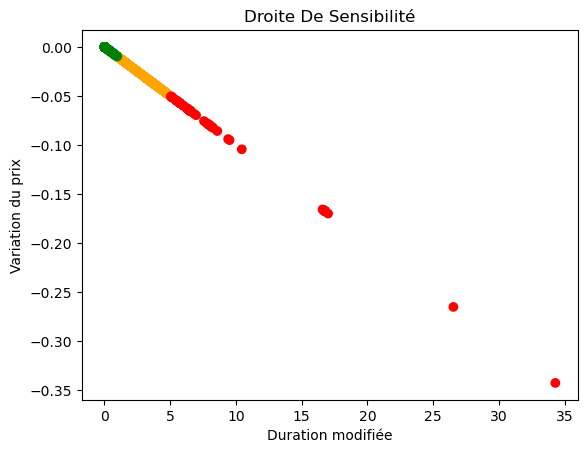

In [31]:
colors = dataset["risk_level"].map({
    "Low": "green",
    "Medium": "orange",
    "High": "red"
})

plt.scatter(dataset["duration_mod"], dataset["variation_prix_sen"], c=colors)
plt.xlabel("Duration modifiée")
plt.ylabel("Variation du prix")
plt.title("Droite De Sensibilité")
plt.show()

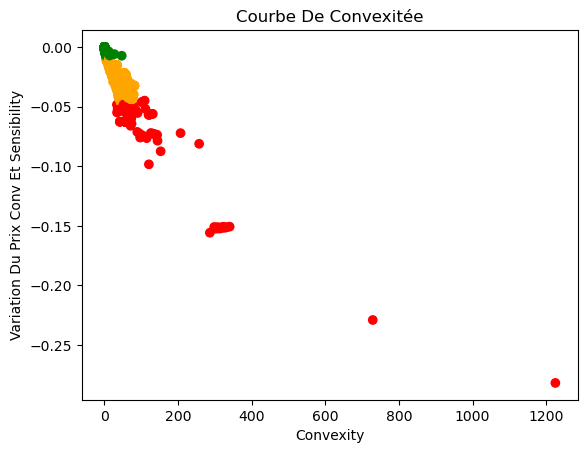

In [32]:
colors = dataset["risk_level"].map({
    "Low": "green",
    "Medium": "orange",
    "High": "red"
})

plt.scatter(dataset["convexity"], dataset["var_prix_sens_convex"], c=colors)
plt.xlabel("Convexity")
plt.ylabel("Variation Du Prix Conv Et Sensibility")
plt.title("Courbe De Convexitée")
plt.show()

In [33]:
import os
os.makedirs('figures', exist_ok=True)

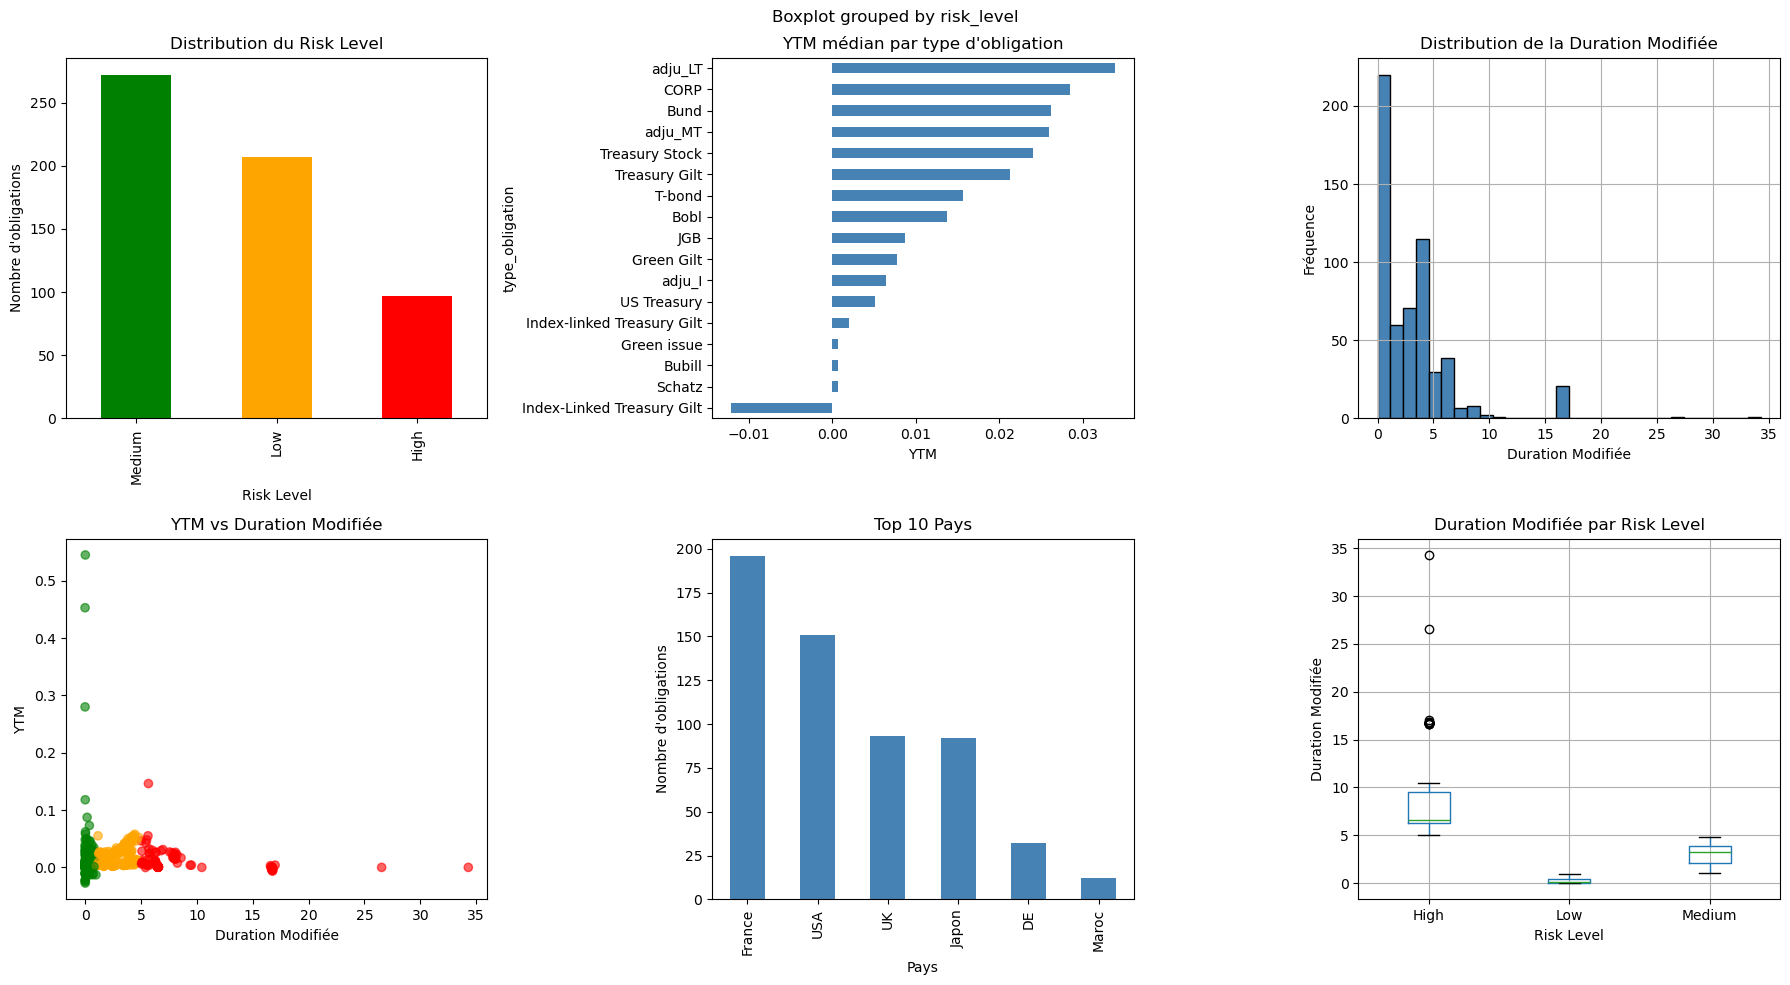

In [34]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Distribution du risk_level
dataset['risk_level'].value_counts().plot(kind='bar', ax=axes[0,0], color=['green', 'orange', 'red'])
axes[0,0].set_title('Distribution du Risk Level')
axes[0,0].set_xlabel('Risk Level')
axes[0,0].set_ylabel('Nombre d\'obligations')

# 2. YTM par type_obligation
dataset.groupby('type_obligation')['ytm_calculee'].median().sort_values().plot(
    kind='barh', ax=axes[0,1], color='steelblue')
axes[0,1].set_title('YTM médian par type d\'obligation')
axes[0,1].set_xlabel('YTM')

# 3. Distribution de la duration_mod
dataset['duration_mod'].hist(bins=30, ax=axes[0,2], color='steelblue', edgecolor='black')
axes[0,2].set_title('Distribution de la Duration Modifiée')
axes[0,2].set_xlabel('Duration Modifiée')
axes[0,2].set_ylabel('Fréquence')

# 4. YTM vs Duration modifiée
colors = dataset['risk_level'].map({'Low': 'green', 'Medium': 'orange', 'High': 'red'})
axes[1,0].scatter(dataset['duration_mod'], dataset['ytm_calculee'], c=colors, alpha=0.6)
axes[1,0].set_title('YTM vs Duration Modifiée')
axes[1,0].set_xlabel('Duration Modifiée')
axes[1,0].set_ylabel('YTM')

# 5. Distribution par pays
dataset['Pays'].value_counts().head(10).plot(kind='bar', ax=axes[1,1], color='steelblue')
axes[1,1].set_title('Top 10 Pays')
axes[1,1].set_xlabel('Pays')
axes[1,1].set_ylabel('Nombre d\'obligations')

# 6. Boxplot duration_mod par risk_level
dataset.boxplot(column='duration_mod', by='risk_level', ax=axes[1,2])
axes[1,2].set_title('Duration Modifiée par Risk Level')
axes[1,2].set_xlabel('Risk Level')
axes[1,2].set_ylabel('Duration Modifiée')
# Enregistrer figure prémière partie
plt.savefig('figures/partie1_analyse_financiere.png', 
            dpi=300, bbox_inches='tight', 
            facecolor='white')
plt.tight_layout()
plt.show()

### Partie 2 du projet

In [35]:
dataset.head()

,type_obligation,date_emission,isin,Coupon,date_maturite,ytm,prix,benchmark,Pays,devise,...,statut,freq,ytm_calculee,duration_mac,duration_mod,sensibility,variation_prix_sen,risk_level,convexity,var_prix_sens_convex
0,US Treasury,2026-02-19,912810US5,0.0238,2056-02-15,0.025,97.933562,FED,USA,US,...,active,2,0.015055,6.081601,5.991399,-5.991399,-0.059914,High,90.042560,-0.055412
1,US Treasury,2026-01-22,91282CPU9,0.0188,2036-01-15,0.020,99.413260,FED,USA,US,...,active,2,0.010219,0.787920,0.779949,-0.779949,-0.007799,Low,5.441820,-0.007527
2,US Treasury,2025-10-23,91282CPH8,0.0113,2030-10-15,0.012,99.726133,FED,USA,US,...,active,2,0.006049,0.122708,0.121970,-0.121970,-0.001220,Low,0.497052,-0.001195
3,US Treasury,2025-07-24,91282CNS6,0.0188,2035-07-15,0.017,101.262744,FED,USA,US,...,active,2,0.009038,0.710861,0.704494,-0.704494,-0.007045,Low,4.751264,-0.006807
4,US Treasury,2025-04-17,91282CNB3,0.0163,2030-04-15,0.017,99.634784,FED,USA,US,...,active,2,0.008785,0.140139,0.138918,-0.138918,-0.001389,Low,0.517141,-0.001363


In [36]:
dataset.tail()

,type_obligation,date_emission,isin,Coupon,date_maturite,ytm,prix,benchmark,Pays,devise,...,statut,freq,ytm_calculee,duration_mac,duration_mod,sensibility,variation_prix_sen,risk_level,convexity,var_prix_sens_convex
571,JGB,2025-05-29,Inconu,0.031,2065-03-20,0.03135,99.20,BOJ,Japon,JPY,...,active,2,0.021999,8.402098,8.221238,-8.221238,-0.082212,High,114.676392,-0.076479
572,JGB,2025-07-24,Inconu,0.031,2065-03-20,0.03375,94.01,BOJ,Japon,JPY,...,active,2,0.023976,8.145957,7.955220,-7.955220,-0.079552,High,103.672700,-0.074369
573,JGB,2025-09-26,Inconu,0.031,2065-03-20,0.03300,95.60,BOJ,Japon,JPY,...,active,2,0.023349,8.227045,8.039331,-8.039331,-0.080393,High,107.067280,-0.075040
574,JGB,2025-11-27,Inconu,0.031,2065-03-20,0.03555,90.40,BOJ,Japon,JPY,...,active,2,0.025476,7.952788,7.755216,-7.755216,-0.077552,High,95.900097,-0.072757
575,JGB,2026-01-29,Inconu,0.031,2065-03-20,0.03720,87.27,BOJ,Japon,JPY,...,active,2,0.026871,7.774600,7.571155,-7.571155,-0.075712,High,89.102777,-0.071256


In [37]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 576 entries, 0 to 575
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   type_obligation       576 non-null    object        
 1   date_emission         576 non-null    datetime64[ns]
 2   isin                  576 non-null    object        
 3   Coupon                576 non-null    float64       
 4   date_maturite         576 non-null    datetime64[ns]
 5   ytm                   576 non-null    float64       
 6   prix                  576 non-null    float64       
 7   benchmark             576 non-null    object        
 8   Pays                  576 non-null    object        
 9   devise                576 non-null    object        
 10  maturity_years        576 non-null    float64       
 11  statut                576 non-null    object        
 12  freq                  576 non-null    int64         
 13  ytm_calculee        

In [38]:
dataset.isna().sum()

type_obligation         0
date_emission           0
isin                    0
Coupon                  0
date_maturite           0
ytm                     0
prix                    0
benchmark               0
Pays                    0
devise                  0
maturity_years          0
statut                  0
freq                    0
ytm_calculee            0
duration_mac            0
duration_mod            0
sensibility             0
variation_prix_sen      0
risk_level              0
convexity               0
var_prix_sens_convex    0
dtype: int64

In [39]:
print(dataset.duplicated().sum())

0


In [40]:
print(dataset.columns.tolist())

['type_obligation', 'date_emission', 'isin', 'Coupon', 'date_maturite', 'ytm', 'prix', 'benchmark', 'Pays', 'devise', 'maturity_years', 'statut', 'freq', 'ytm_calculee', 'duration_mac', 'duration_mod', 'sensibility', 'variation_prix_sen', 'risk_level', 'convexity', 'var_prix_sens_convex']


In [41]:
print(dataset[["ytm_calculee","var_prix_sens_convex","duration_mod", "convexity"]])

     ytm_calculee  var_prix_sens_convex  duration_mod   convexity
0        0.015055             -0.055412      5.991399   90.042560
1        0.010219             -0.007527      0.779949    5.441820
2        0.006049             -0.001195      0.121970    0.497052
3        0.009038             -0.006807      0.704494    4.751264
4        0.008785             -0.001363      0.138918    0.517141
..            ...                   ...           ...         ...
571      0.021999             -0.076479      8.221238  114.676392
572      0.023976             -0.074369      7.955220  103.672700
573      0.023349             -0.075040      8.039331  107.067280
574      0.025476             -0.072757      7.755216   95.900097
575      0.026871             -0.071256      7.571155   89.102777

[576 rows x 4 columns]


In [42]:
features = ["ytm_calculee","var_prix_sens_convex","duration_mod", "convexity"]
X = dataset[features]

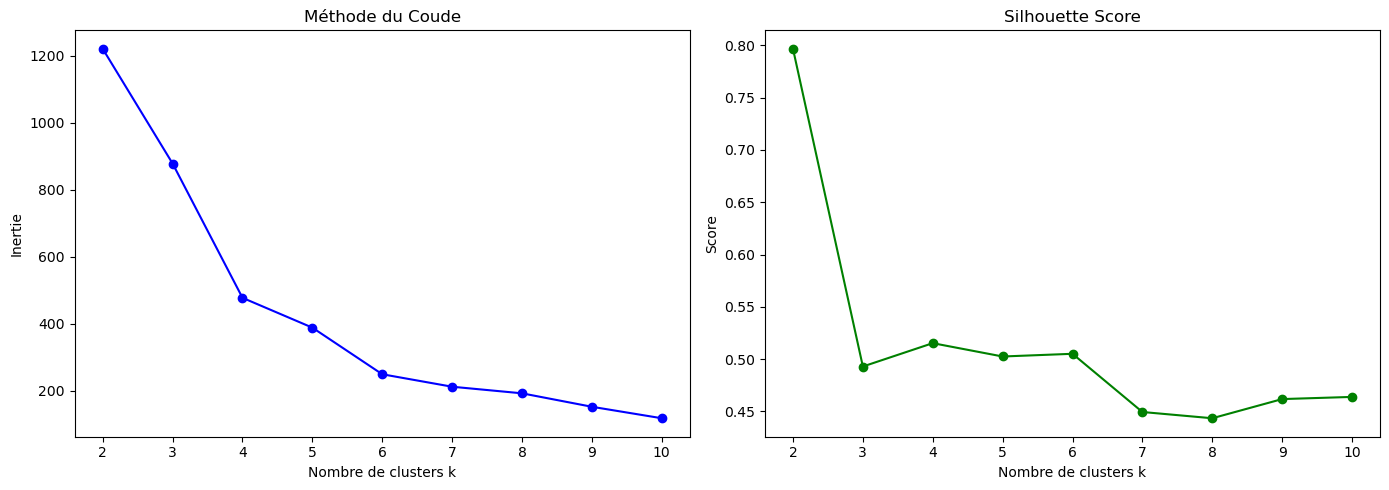

In [43]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(dataset[features])
# Méthode du coude
inertias = []
silhouettes = []
K = range(2, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X_scaled, kmeans.labels_))

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K, inertias, 'bo-')
axes[0].set_title('Méthode du Coude')
axes[0].set_xlabel('Nombre de clusters k')
axes[0].set_ylabel('Inertie')

axes[1].plot(K, silhouettes, 'go-')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('Nombre de clusters k')
axes[1].set_ylabel('Score')

plt.tight_layout()
plt.show()

In [44]:
pipelines = {
    "KMeans" : Pipeline([
        ("scaler", StandardScaler()),
        ("model", KMeans(n_clusters=3, random_state=42))
    ]),
    "Agglomerative" : Pipeline([
        ("scaler", StandardScaler()),
        ("model", AgglomerativeClustering(n_clusters=3))
    ]),
    "DBSCAN" : Pipeline([
        ("scaler", StandardScaler()),
        ("model", DBSCAN(eps=0.5, min_samples=5))
    ])
}
resultats={}
for nom, modele in pipelines.items():
    modele.fit(X)
    labels = modele["model"].labels_
    X_scaled_pipe = modele["scaler"].transform(X)
    resultats[nom] = {
        'silhouette'  : silhouette_score(X_scaled_pipe, labels),
        'davies_bouldin' : davies_bouldin_score(X_scaled_pipe, labels),
        'calinski'    : calinski_harabasz_score(X_scaled_pipe, labels)
    }
results_df = pd.DataFrame(resultats).T
print(results_df)

               silhouette  davies_bouldin    calinski
KMeans           0.492976        0.698860  464.910748
Agglomerative    0.809717        0.333466  522.869620
DBSCAN           0.778844        1.507101  238.708101


In [45]:
from itertools import product
# Hyperparamètres à tester
linkages = ['ward', 'complete', 'average', 'single']
metrics  = ['euclidean', 'manhattan', 'cosine']
results_grid = {}
for linkage, metric in product(linkages, metrics):
    # ward fonctionne uniquement avec euclidean
    if linkage == 'ward' and metric != 'euclidean':
        continue
    try:
        model = AgglomerativeClustering(
            n_clusters=3,
            linkage=linkage,
            metric=metric
        )
        labels = model.fit_predict(X_scaled)
        
        results_grid[f"{linkage}_{metric}"] = {
            'silhouette'     : silhouette_score(X_scaled, labels),
            'davies_bouldin' : davies_bouldin_score(X_scaled, labels),
            'calinski'       : calinski_harabasz_score(X_scaled, labels)
        }
    except:
        continue

results_grid_df = pd.DataFrame(results_grid).T
print(results_grid_df.sort_values('silhouette', ascending=False).head(5))

                    silhouette  davies_bouldin    calinski
average_euclidean     0.855075        0.265531  132.190488
complete_euclidean    0.852933        0.322803  166.034641
average_manhattan     0.852933        0.322803  166.034641
complete_manhattan    0.852933        0.322803  166.034641
single_manhattan      0.834253        0.090914   70.649640


In [46]:
best_model = AgglomerativeClustering(
    n_clusters=3,
    linkage='ward',
    metric='euclidean'
)
dataset['cluster'] = best_model.fit_predict(X_scaled)
print(f"Silhouette Score     : {silhouette_score(X_scaled, dataset['cluster']):.4f}")
print(f"Davies-Bouldin Score : {davies_bouldin_score(X_scaled, dataset['cluster']):.4f}")
print(f"Calinski-Harabasz    : {calinski_harabasz_score(X_scaled, dataset['cluster']):.4f}")
print("\nDistribution :")
print(dataset['cluster'].value_counts())
print("\nProfil moyen :")
print(dataset.groupby('cluster')[features].mean())

Silhouette Score     : 0.8097
Davies-Bouldin Score : 0.3335
Calinski-Harabasz    : 522.8696

Distribution :
cluster
0    550
1     23
2      3
Name: count, dtype: int64

Profil moyen :
         ytm_calculee  var_prix_sens_convex  duration_mod   convexity
cluster                                                              
0            0.016897             -0.023288      2.484743   31.184945
1           -0.001300             -0.160747     17.928846  370.823446
2            0.426017             -0.000083      0.008295    0.007324


In [47]:
cluster_map = {
    0 : 'Medium',
    1 : 'High',
    2 : 'Low'
}

dataset['risk_level_ml'] = dataset['cluster'].map(cluster_map)

print(pd.crosstab(dataset['risk_level'], dataset['risk_level_ml']))

risk_level_ml  High  Low  Medium
risk_level                      
High             23    0      74
Low               0    3     204
Medium            0    0     272


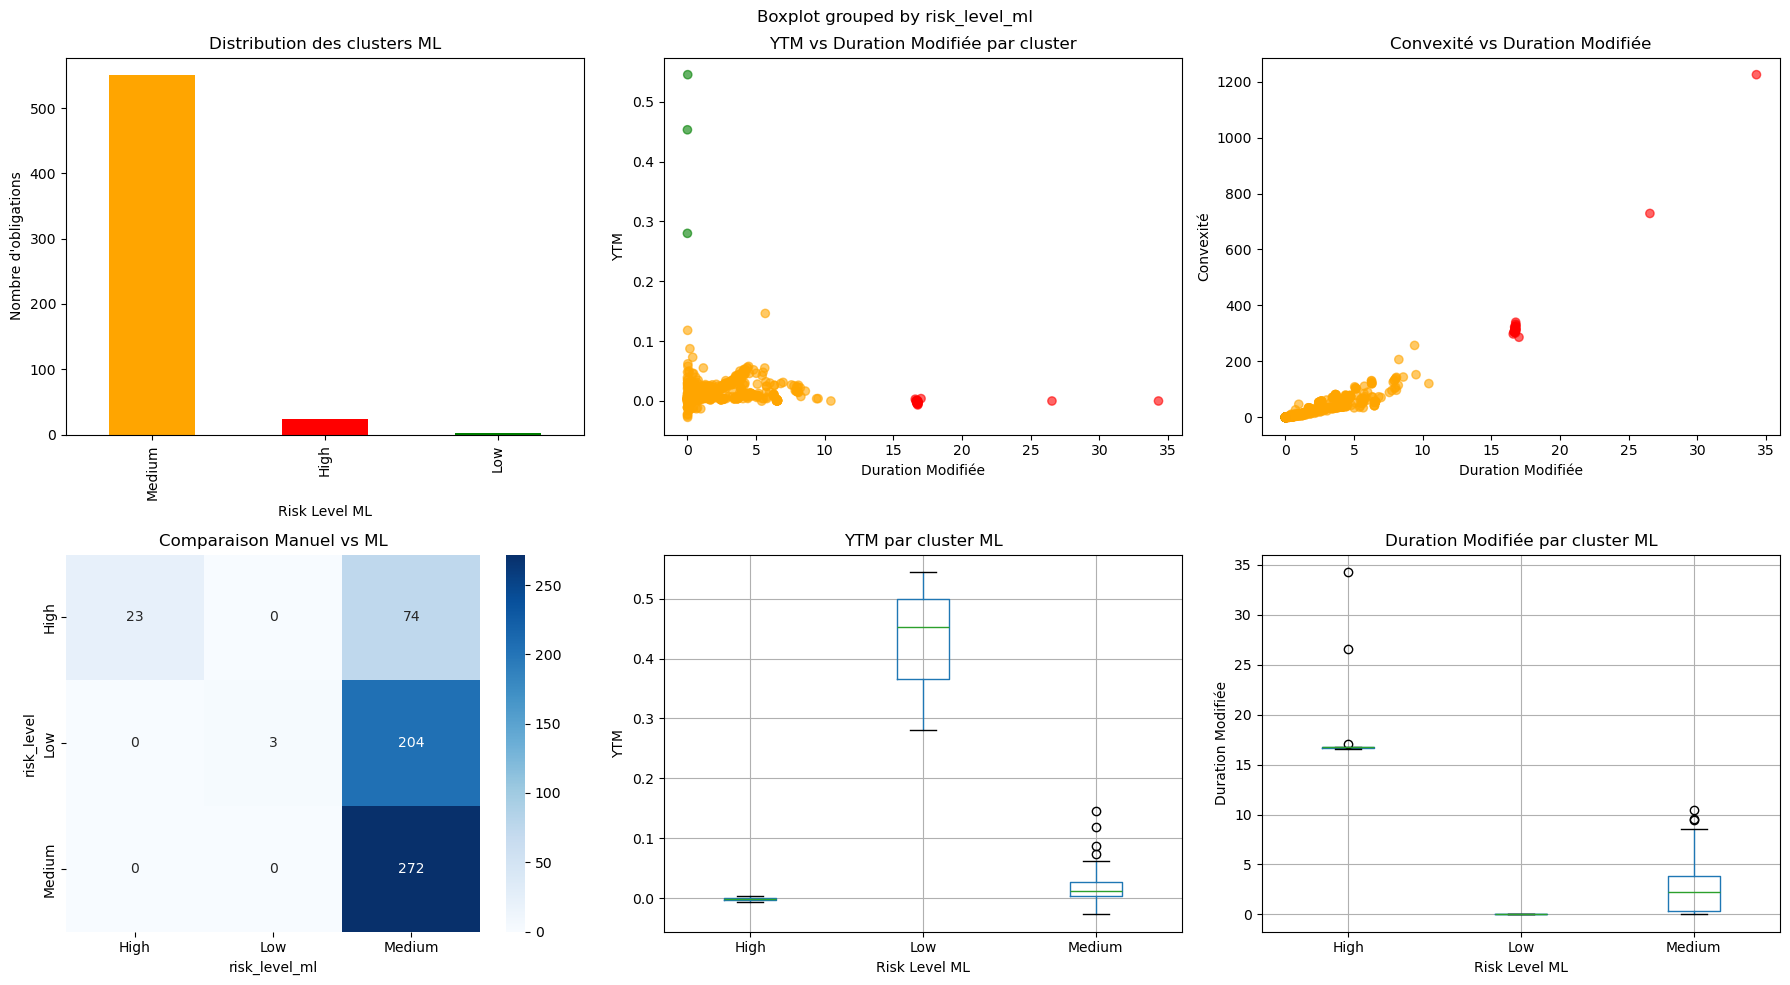

In [48]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

colors = dataset['risk_level_ml'].map({'Low': 'green', 'Medium': 'orange', 'High': 'red'})

# 1. Distribution des clusters ML
dataset['risk_level_ml'].value_counts().plot(
    kind='bar', ax=axes[0,0], color=['orange', 'red', 'green'])
axes[0,0].set_title('Distribution des clusters ML')
axes[0,0].set_xlabel('Risk Level ML')
axes[0,0].set_ylabel('Nombre d\'obligations')

# 2. YTM vs Duration Modifiée par cluster
axes[0,1].scatter(dataset['duration_mod'], dataset['ytm_calculee'], c=colors, alpha=0.6)
axes[0,1].set_title('YTM vs Duration Modifiée par cluster')
axes[0,1].set_xlabel('Duration Modifiée')
axes[0,1].set_ylabel('YTM')

# 3. Convexité vs Duration Modifiée
axes[0,2].scatter(dataset['duration_mod'], dataset['convexity'], c=colors, alpha=0.6)
axes[0,2].set_title('Convexité vs Duration Modifiée')
axes[0,2].set_xlabel('Duration Modifiée')
axes[0,2].set_ylabel('Convexité')

# 4. Comparaison manuel vs ML
crosstab = pd.crosstab(dataset['risk_level'], dataset['risk_level_ml'])
sns.heatmap(crosstab, annot=True, fmt='d', cmap='Blues', ax=axes[1,0])
axes[1,0].set_title('Comparaison Manuel vs ML')

# 5. Boxplot YTM par cluster ML
dataset.boxplot(column='ytm_calculee', by='risk_level_ml', ax=axes[1,1])
axes[1,1].set_title('YTM par cluster ML')
axes[1,1].set_xlabel('Risk Level ML')
axes[1,1].set_ylabel('YTM')

# 6. Boxplot Duration par cluster ML
dataset.boxplot(column='duration_mod', by='risk_level_ml', ax=axes[1,2])
axes[1,2].set_title('Duration Modifiée par cluster ML')
axes[1,2].set_xlabel('Risk Level ML')
axes[1,2].set_ylabel('Duration Modifiée')
# Enregistrer Partie 2
plt.savefig('figures/partie2_segmentation_ml.png',
            dpi=300, bbox_inches='tight',
            facecolor='white')
plt.tight_layout()
plt.show()

### Partie 3

In [49]:
print(dataset["Pays"].unique())

['USA' 'DE' 'Maroc' 'France' 'UK' 'Japon']


In [50]:
import yfinance as yf
data = yf.download("^TNX", start="2015-01-01", end="2025-12-31", progress=False)
taux_us = data["Close"].resample('ME').mean()/100
# Spreads historiques moyens par rapport au taux US
# Source : conventions de marché connues
spreads = {
    'USA'    :  0.000,   # référence
    'DE'     : -0.015,   # Bund toujours < US (-1.5%)
    'France' : -0.010,   # OAT légèrement < US (~-1%)
    'UK'     : -0.005,   # Gilt proche US (~-0.5%)
    'Japon'  : -0.030,   # JGB très bas (~-3%)
    'Maroc'  :  0.005,   # proxy France + prime (~+0.5%)
}
taux_par_pays = {}
for pays, spread in spreads.items():
    taux_par_pays[pays] = taux_us + spread

# Vérification
for pays, taux in taux_par_pays.items():
    moyenne = float(taux.mean().iloc[0])
    print(f"{pays} : moyenne = {moyenne:.4f} ({moyenne*100:.2f}%)")

USA : moyenne = 0.0264 (2.64%)
DE : moyenne = 0.0114 (1.14%)
France : moyenne = 0.0164 (1.64%)
UK : moyenne = 0.0214 (2.14%)
Japon : moyenne = -0.0036 (-0.36%)
Maroc : moyenne = 0.0314 (3.14%)


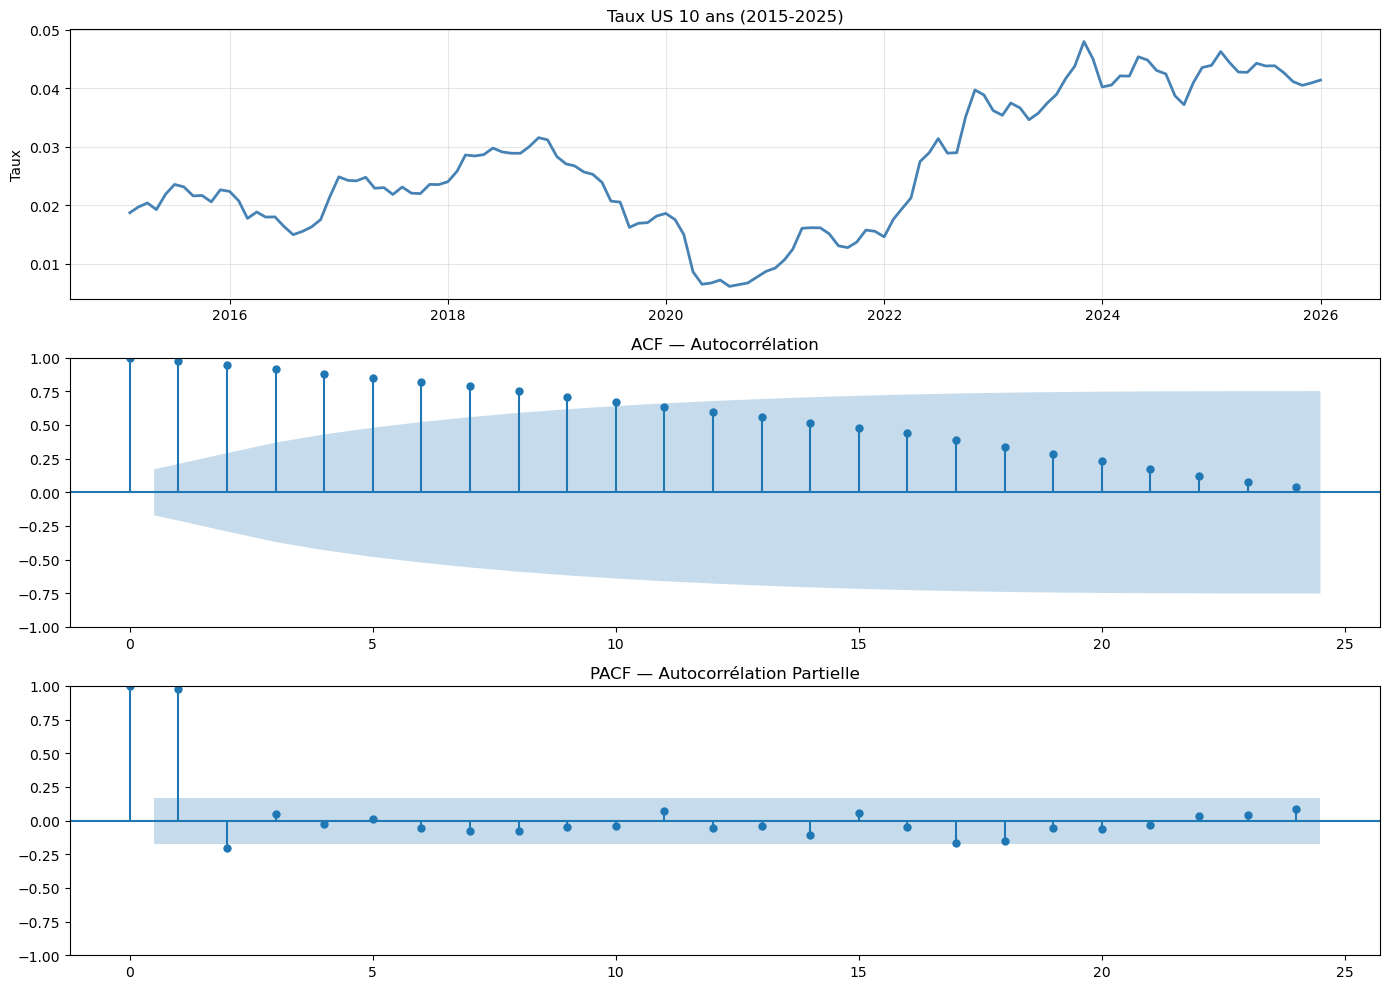


Test ADF :
Statistique : -0.8961
p-value     : 0.7893
Série non stationnaire ✗


In [51]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

# Série US comme base
serie = taux_par_pays['USA'].copy()
serie.index = pd.to_datetime(serie.index)

# Visualisation
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# 1. Série brute
axes[0].plot(serie, color='steelblue', linewidth=2)
axes[0].set_title('Taux US 10 ans (2015-2025)')
axes[0].set_ylabel('Taux')
axes[0].grid(True, alpha=0.3)

# 2. ACF
plot_acf(serie.dropna(), lags=24, ax=axes[1])
axes[1].set_title('ACF — Autocorrélation')

# 3. PACF
plot_pacf(serie.dropna(), lags=24, ax=axes[2])
axes[2].set_title('PACF — Autocorrélation Partielle')

plt.tight_layout()
plt.show()

# Test ADF — stationnarité
result = adfuller(serie.dropna())
print(f"\nTest ADF :")
print(f"Statistique : {result[0]:.4f}")
print(f"p-value     : {result[1]:.4f}")
print(f"Série {'stationnaire ✓' if result[1] < 0.05 else 'non stationnaire ✗'}")

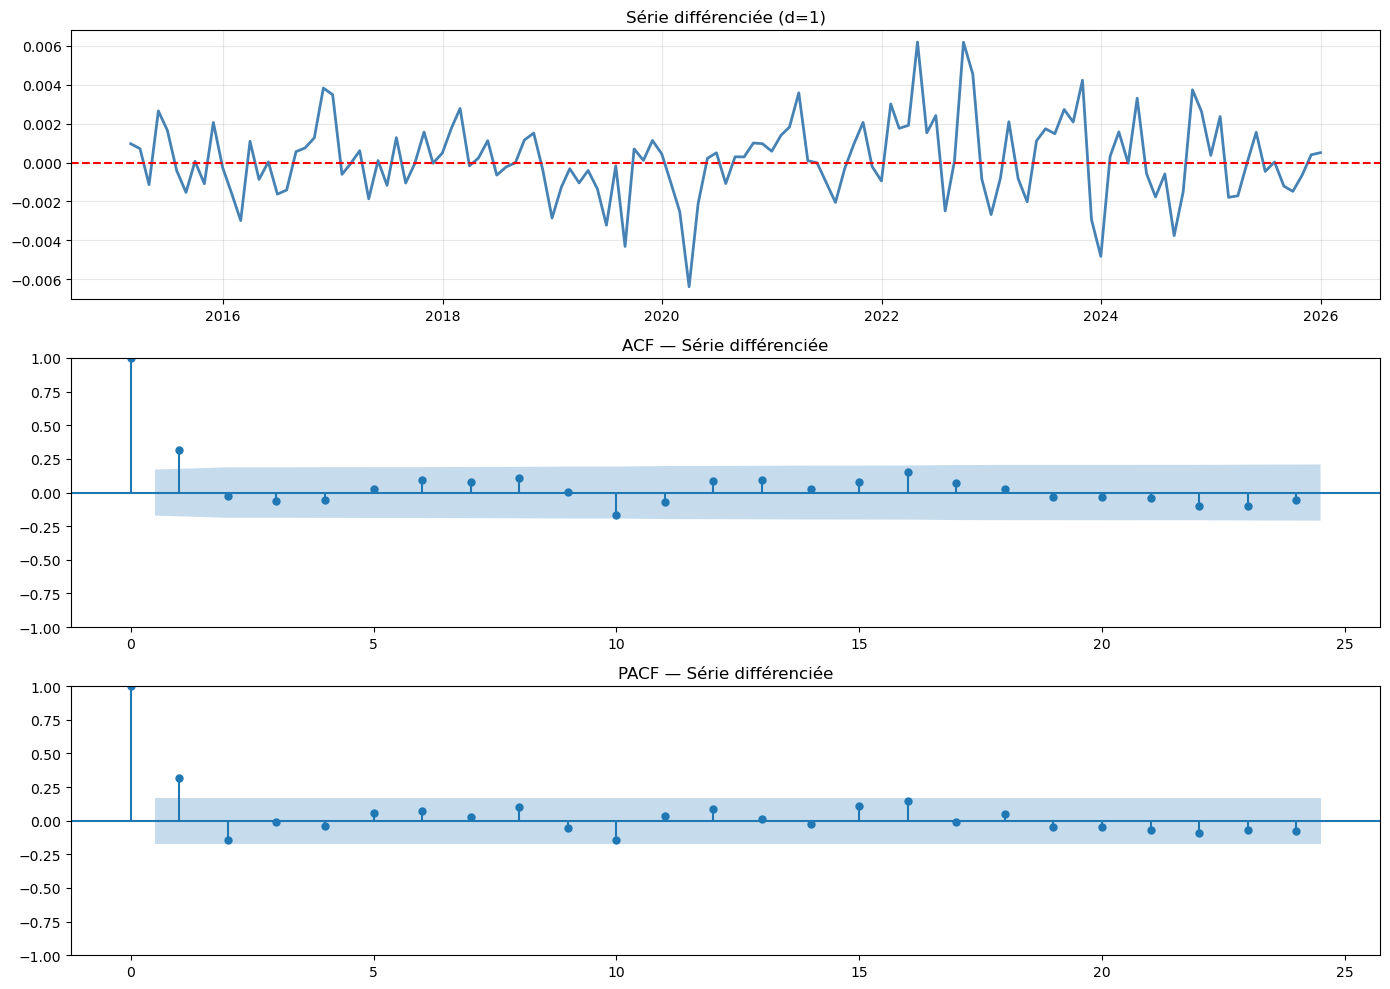

Test ADF après différenciation :
p-value : 0.0000
Série stationnaire ✓


In [52]:
# Différencier la série
serie_diff = serie.diff().dropna()

# Re-visualiser
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

axes[0].plot(serie_diff, color='steelblue', linewidth=2)
axes[0].set_title('Série différenciée (d=1)')
axes[0].axhline(y=0, color='red', linestyle='--')
axes[0].grid(True, alpha=0.3)

plot_acf(serie_diff, lags=24, ax=axes[1])
axes[1].set_title('ACF — Série différenciée')

plot_pacf(serie_diff, lags=24, ax=axes[2])
axes[2].set_title('PACF — Série différenciée')

plt.tight_layout()
plt.show()

# Re-test ADF
result = adfuller(serie_diff)
print(f"Test ADF après différenciation :")
print(f"p-value : {result[1]:.4f}")
print(f"Série {'stationnaire ✓' if result[1] < 0.05 else 'non stationnaire ✗'}")

In [53]:
model_auto = auto_arima(
    serie,
    seasonal    = False,
    d           = 1,        # on impose d=1
    start_p     = 0,
    max_p       = 3,
    start_q     = 0,
    max_q       = 3,
    information_criterion = 'aic',
    trace       = True,     # affiche les modèles testés
    stepwise    = True
)

print(f"\nMeilleur modèle : {model_auto.order}")
print(model_auto.summary())

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-1256.668, Time=0.37 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-1268.450, Time=0.20 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-1270.835, Time=0.11 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-1257.658, Time=0.10 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=-1268.836, Time=0.24 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=-1268.824, Time=0.14 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=-1266.825, Time=0.18 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=-1272.209, Time=0.10 sec
 ARIMA(1,1,1)(0,0,0)[0]             : AIC=-1270.210, Time=0.09 sec
 ARIMA(0,1,2)(0,0,0)[0]             : AIC=-1270.202, Time=0.11 sec
 ARIMA(1,1,0)(0,0,0)[0]             : AIC=-1269.900, Time=0.07 sec
 ARIMA(1,1,2)(0,0,0)[0]             : AIC=-1268.195, Time=0.29 sec

Best model:  ARIMA(0,1,1)(0,0,0)[0]          
Total fit time: 2.025 seconds

Meilleur modèle : (0, 1, 1)
                               SARIMAX Results 

Train : 105 observations (2015-01-31 → 2023-09-30)
Test  : 27 observations (2023-10-31 → 2025-12-31)
                               SARIMAX Results                                
Dep. Variable:                   ^TNX   No. Observations:                  105
Model:                 ARIMA(0, 1, 1)   Log Likelihood                 509.482
Date:                Mon, 25 May 2026   AIC                          -1014.963
Time:                        20:40:58   BIC                          -1009.675
Sample:                    01-31-2015   HQIC                         -1012.821
                         - 09-30-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1          0.3940      0.086      4.575      0.000       0.225       0.563
sigma2      3.239e-06   3.87e-

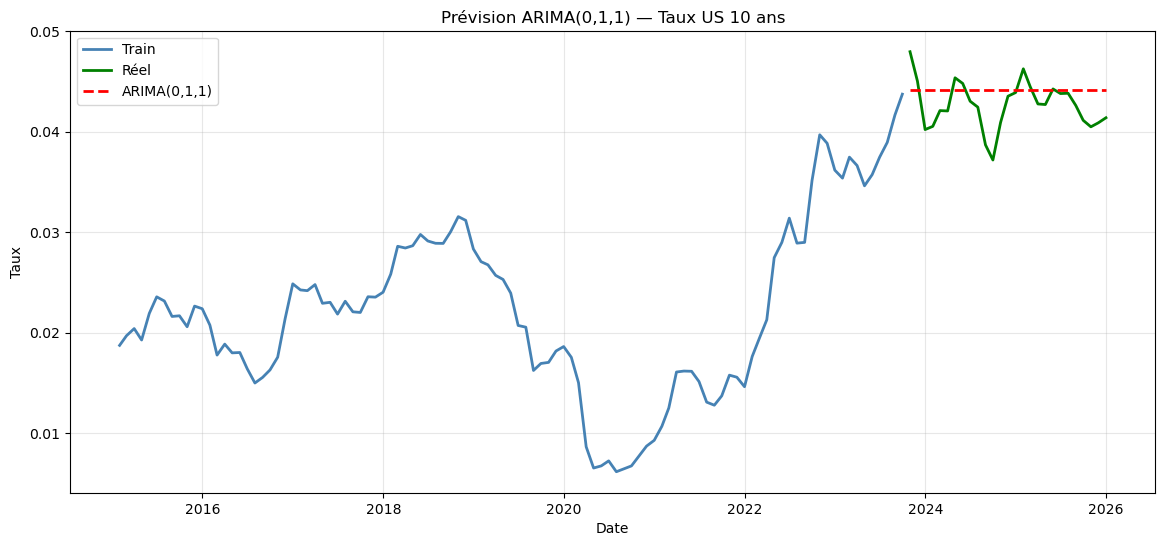

In [54]:
# Split chronologique 80/20
split = int(len(serie) * 0.8)
train = serie.iloc[:split]
test  = serie.iloc[split:]

print(f"Train : {len(train)} observations ({train.index[0].date()} → {train.index[-1].date()})")
print(f"Test  : {len(test)} observations ({test.index[0].date()} → {test.index[-1].date()})")

# Entraîner ARIMA(0,1,1)
model_arima = ARIMA(train, order=(0, 1, 1))
result_arima = model_arima.fit()

print(result_arima.summary())

# Prévisions sur test
predictions = result_arima.forecast(steps=len(test))

# Métriques
mae  = mean_absolute_error(test, predictions)
rmse = np.sqrt(mean_squared_error(test, predictions))
mape = np.mean(np.abs((test.values - predictions.values) / test.values)) * 100

print(f"\nMAE  : {mae:.6f}")
print(f"RMSE : {rmse:.6f}")
print(f"MAPE : {mape:.2f}%")

# Visualisation
plt.figure(figsize=(14, 6))
plt.plot(train, label='Train', color='steelblue', linewidth=2)
plt.plot(test, label='Réel', color='green', linewidth=2)
plt.plot(predictions, label='ARIMA(0,1,1)', color='red', linestyle='--', linewidth=2)
plt.title('Prévision ARIMA(0,1,1) — Taux US 10 ans')
plt.xlabel('Date')
plt.ylabel('Taux')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

X_train : (96, 12, 1)
X_test  : (24, 12, 1)


D:\ANACONDA JUPYTER\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 32)                  │           4,352 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,385 (17.13 KB)

 Trainable params: 4,385 (17.13 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 239ms/step - loss: 0.1601 - mae: 0.3519 - val_loss: 0.6149 - val_mae: 0.7736 - learning_rate: 0.0010
Epoch 2/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - loss: 0.1069 - mae: 0.2843 - val_loss: 0.4513 - val_mae: 0.6624 - learning_rate: 0.0010
Epoch 3/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.0660 - mae: 0.2205 - val_loss: 0.3035 - val_mae: 0.5424 - learning_rate: 0.0010
Epoch 4/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 0.0345 - mae: 0.1552 - val_loss: 0.1737 - val_mae: 0.4085 - learning_rate: 0.0010
Epoch 5/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 0.0228 - mae: 0.1221 - val_loss: 0.0811 - val_mae: 0.2740 - learning_rate: 0.0010
Epoch 6/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - loss: 0.0215 - mae: 0.1181 - val_loss: 0.0583 - val_mae: 0.2284 - learning_rate: 0.0010
Epoch 7/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.0222 - mae: 0.1177 - val_loss: 0.0775 - val_mae: 0.2673 - learning_rate: 0.0010
Epoch 8/200
5/5 ━━━

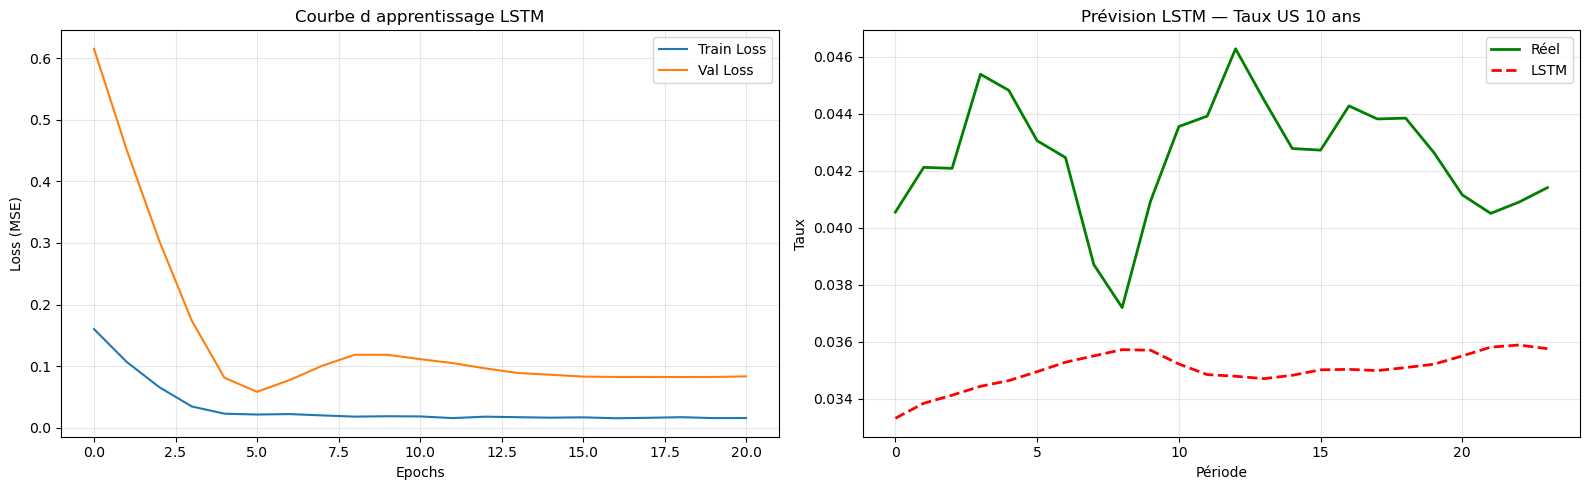

In [55]:
# 1. Normalisation
serie_values = serie.values.reshape(-1, 1)
scaler = MinMaxScaler(feature_range=(0, 1))
serie_scaled = scaler.fit_transform(serie_values)

# 2. Création des séquences
def create_sequences(data, lookback=12):
    X, y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i-lookback:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

lookback = 12
X, y = create_sequences(serie_scaled, lookback)

# 3. Reshape 3D
X = X.reshape(X.shape[0], X.shape[1], 1)

# 4. Split chronologique
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")

# 5. Architecture LSTM
model_lstm = Sequential([
    LSTM(32, input_shape=(lookback, 1)),
    Dropout(0.1),
    Dense(1)
])

model_lstm.compile(optimizer='adam', loss='mse', metrics=['mae'])
model_lstm.summary()

# 6. Callbacks
callbacks_list = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True),
    ModelCheckpoint('best_lstm_taux.keras', save_best_only=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)
]

# 7. Entraînement
history = model_lstm.fit(
    X_train, y_train,
    epochs           = 200,
    batch_size       = 16,
    validation_split = 0.2,
    callbacks        = callbacks_list,
    verbose          = 1
)

# 8. Prévisions
y_pred_scaled = model_lstm.predict(X_test)

# 9. Dénormalisation
y_pred = scaler.inverse_transform(y_pred_scaled)
y_test_real = scaler.inverse_transform(y_test.reshape(-1, 1))

# 10. Métriques
mae  = mean_absolute_error(y_test_real, y_pred)
rmse = np.sqrt(mean_squared_error(y_test_real, y_pred))
mape = np.mean(np.abs((y_test_real - y_pred) / y_test_real)) * 100

print(f"\nMAE  : {mae:.6f}")
print(f"RMSE : {rmse:.6f}")
print(f"MAPE : {mape:.2f}%")

# 11. Visualisation
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Courbe d'apprentissage
axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Courbe d apprentissage LSTM')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss (MSE)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Prévisions vs Réel
axes[1].plot(y_test_real, label='Réel', color='green', linewidth=2)
axes[1].plot(y_pred, label='LSTM', color='red', linestyle='--', linewidth=2)
axes[1].set_title('Prévision LSTM — Taux US 10 ans')
axes[1].set_xlabel('Période')
axes[1].set_ylabel('Taux')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Prévisions taux US 12 mois :
            Taux prévu  Borne basse  Borne haute
2026-01-31    0.041522     0.037890     0.045154
2026-02-28    0.041522     0.035372     0.047672
2026-03-31    0.041522     0.033619     0.049425
2026-04-30    0.041522     0.032189     0.050854
2026-05-31    0.041522     0.030952     0.052092
2026-06-30    0.041522     0.029844     0.053199
2026-07-31    0.041522     0.028833     0.054210
2026-08-31    0.041522     0.027897     0.055147
2026-09-30    0.041522     0.027021     0.056022
2026-10-31    0.041522     0.026196     0.056848
2026-11-30    0.041522     0.025412     0.057632
2026-12-31    0.041522     0.024665     0.058379


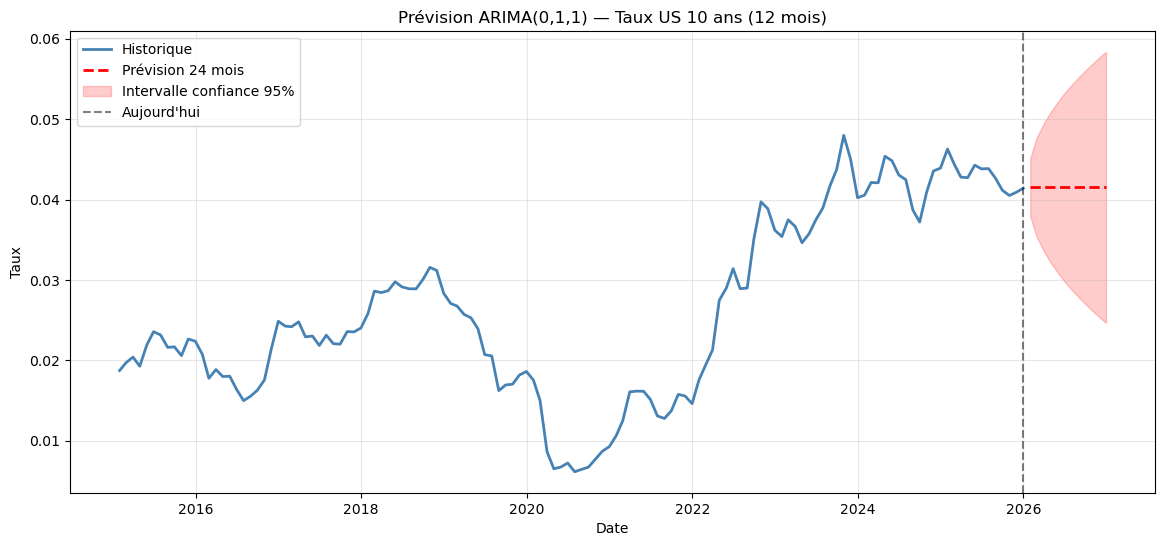

In [56]:
# Réentraîner sur TOUTES les données
model_final = ARIMA(serie, order=(0, 1, 1))
result_final = model_final.fit()

# Prévisions 12 mois futurs
forecast = result_final.get_forecast(steps=12)
forecast_mean = forecast.predicted_mean
forecast_ci   = forecast.conf_int(alpha=0.05)  # intervalle confiance 95%

# Créer index des dates futures
derniere_date = serie.index[-1]
dates_futures = pd.date_range(
    start=derniere_date,
    periods=13,
    freq='ME'
)[1:]  # exclure la première date (déjà connue)

forecast_mean.index = dates_futures
forecast_ci.index   = dates_futures

# Afficher les prévisions
print("Prévisions taux US 12 mois :")
print(pd.DataFrame({
    'Taux prévu' : forecast_mean,
    'Borne basse': forecast_ci.iloc[:, 0],
    'Borne haute': forecast_ci.iloc[:, 1]
}))

# Visualisation
plt.figure(figsize=(14, 6))
plt.plot(serie, label='Historique', color='steelblue', linewidth=2)
plt.plot(forecast_mean, label='Prévision 24 mois',
         color='red', linestyle='--', linewidth=2)
plt.fill_between(dates_futures,
                 forecast_ci.iloc[:, 0],
                 forecast_ci.iloc[:, 1],
                 alpha=0.2, color='red',
                 label='Intervalle confiance 95%')
plt.axvline(x=derniere_date, color='black',
            linestyle='--', alpha=0.5, label='Aujourd\'hui')
plt.title('Prévision ARIMA(0,1,1) — Taux US 10 ans (12 mois)')
plt.xlabel('Date')
plt.ylabel('Taux')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [57]:
# Taux actuel
taux_actuel_us = serie.iloc[-1].iloc[0]
# Taux prévu
taux_predit_us = float(forecast_mean.mean())
# Choc unique pour tous les pays
choc = taux_predit_us - taux_actuel_us
print(f"Taux actuel US : {taux_actuel_us*100:.2f}%")
print(f"Taux prévu US  : {taux_predit_us*100:.2f}%")
print(f"Choc ARIMA US  : {choc*100:.4f}%")
chocs_par_pays = {
    'USA'    : choc,   # ARIMA
    'DE'     : -0.0050,    # BCE
    'France' : -0.0050,    # BCE
    'UK'     : -0.0025,    # BOE
    'Japon'  : +0.0025,    # BOJ
    'Maroc'  : -0.0025,    # BAM
}

# Mapper et calculer
dataset['choc_pays'] = dataset['Pays'].map(chocs_par_pays)
dataset['variation_prix_future'] = (
    -dataset['duration_mod'] * dataset['choc_pays']
    + 0.5 * dataset['convexity'] * dataset['choc_pays']**2
)

# Résultats
print("\nChoc et impact moyen par pays :")
print(dataset.groupby('Pays')[['choc_pays', 'variation_prix_future']].mean())

print("\nImpact moyen par cluster :")
print(dataset.groupby('risk_level_ml')['variation_prix_future'].mean())

Taux actuel US : 4.14%
Taux prévu US  : 4.15%
Choc ARIMA US  : 0.0118%

Choc et impact moyen par pays :
        choc_pays  variation_prix_future
Pays                                    
DE      -0.005000               0.025560
France  -0.005000               0.021276
Japon    0.002500              -0.010810
Maroc   -0.002500               0.006799
UK      -0.002500               0.004861
USA      0.000118              -0.000153

Impact moyen par cluster :
risk_level_ml
High      7.968079e-02
Low      -2.565013e-07
Medium    4.857051e-03
Name: variation_prix_future, dtype: float64


### Partie 4 : Similation de Scénario

In [58]:
# Scénarios par pays
scenarios = {
    'Optimiste'    : {'USA': -0.01,   'DE': -0.015, 'France': -0.015,
                      'UK' : -0.01,   'Japon': -0.005, 'Maroc': -0.01},
    'Base (BC)'    : chocs_par_pays,
    'Modéré'       : {'USA': +0.005,  'DE': -0.0025, 'France': -0.0025,
                      'UK' : +0.0025, 'Japon': +0.005, 'Maroc': +0.0025},
    'Adverse'      : {'USA': +0.01,   'DE': +0.005,  'France': +0.005,
                      'UK' : +0.01,   'Japon': +0.01,  'Maroc': +0.01},
    'Très adverse' : {'USA': +0.02,   'DE': +0.015,  'France': +0.015,
                      'UK' : +0.02,   'Japon': +0.02,  'Maroc': +0.02},
}

resultats_scenarios = {}

for scenario, chocs in scenarios.items():
    dataset[f'choc_{scenario}'] = dataset['Pays'].map(chocs)
    dataset[f'var_{scenario}'] = (
        -dataset['duration_mod'] * dataset[f'choc_{scenario}']
        + 0.5 * dataset['convexity'] * dataset[f'choc_{scenario}']**2
    )
    resultats_scenarios[scenario] = {
        'impact_moyen'  : dataset[f'var_{scenario}'].mean(),
        'impact_High'   : dataset[dataset['risk_level_ml']=='High'][f'var_{scenario}'].mean(),
        'impact_Medium' : dataset[dataset['risk_level_ml']=='Medium'][f'var_{scenario}'].mean(),
        'impact_Low'    : dataset[dataset['risk_level_ml']=='Low'][f'var_{scenario}'].mean(),
        'pire_oblig'    : dataset[f'var_{scenario}'].min(),
        'meilleure_oblig': dataset[f'var_{scenario}'].max(),
    }

df_scenarios = pd.DataFrame(resultats_scenarios).T
print(df_scenarios.to_string())

              impact_moyen  impact_High  impact_Medium    impact_Low  pire_oblig  meilleure_oblig
Optimiste         0.038870     0.292117       0.028491  8.331498e-05    0.000003         0.404196
Base (BC)         0.007820     0.079681       0.004857 -2.565013e-07   -0.020195         0.088623
Modéré           -0.001638     0.026940      -0.002841 -4.069577e-05   -0.156170         0.043417
Adverse          -0.021082    -0.095049      -0.018103 -8.258262e-05   -0.281721        -0.000003
Très adverse     -0.046365    -0.233008      -0.038812 -1.644329e-04   -0.440968        -0.000006


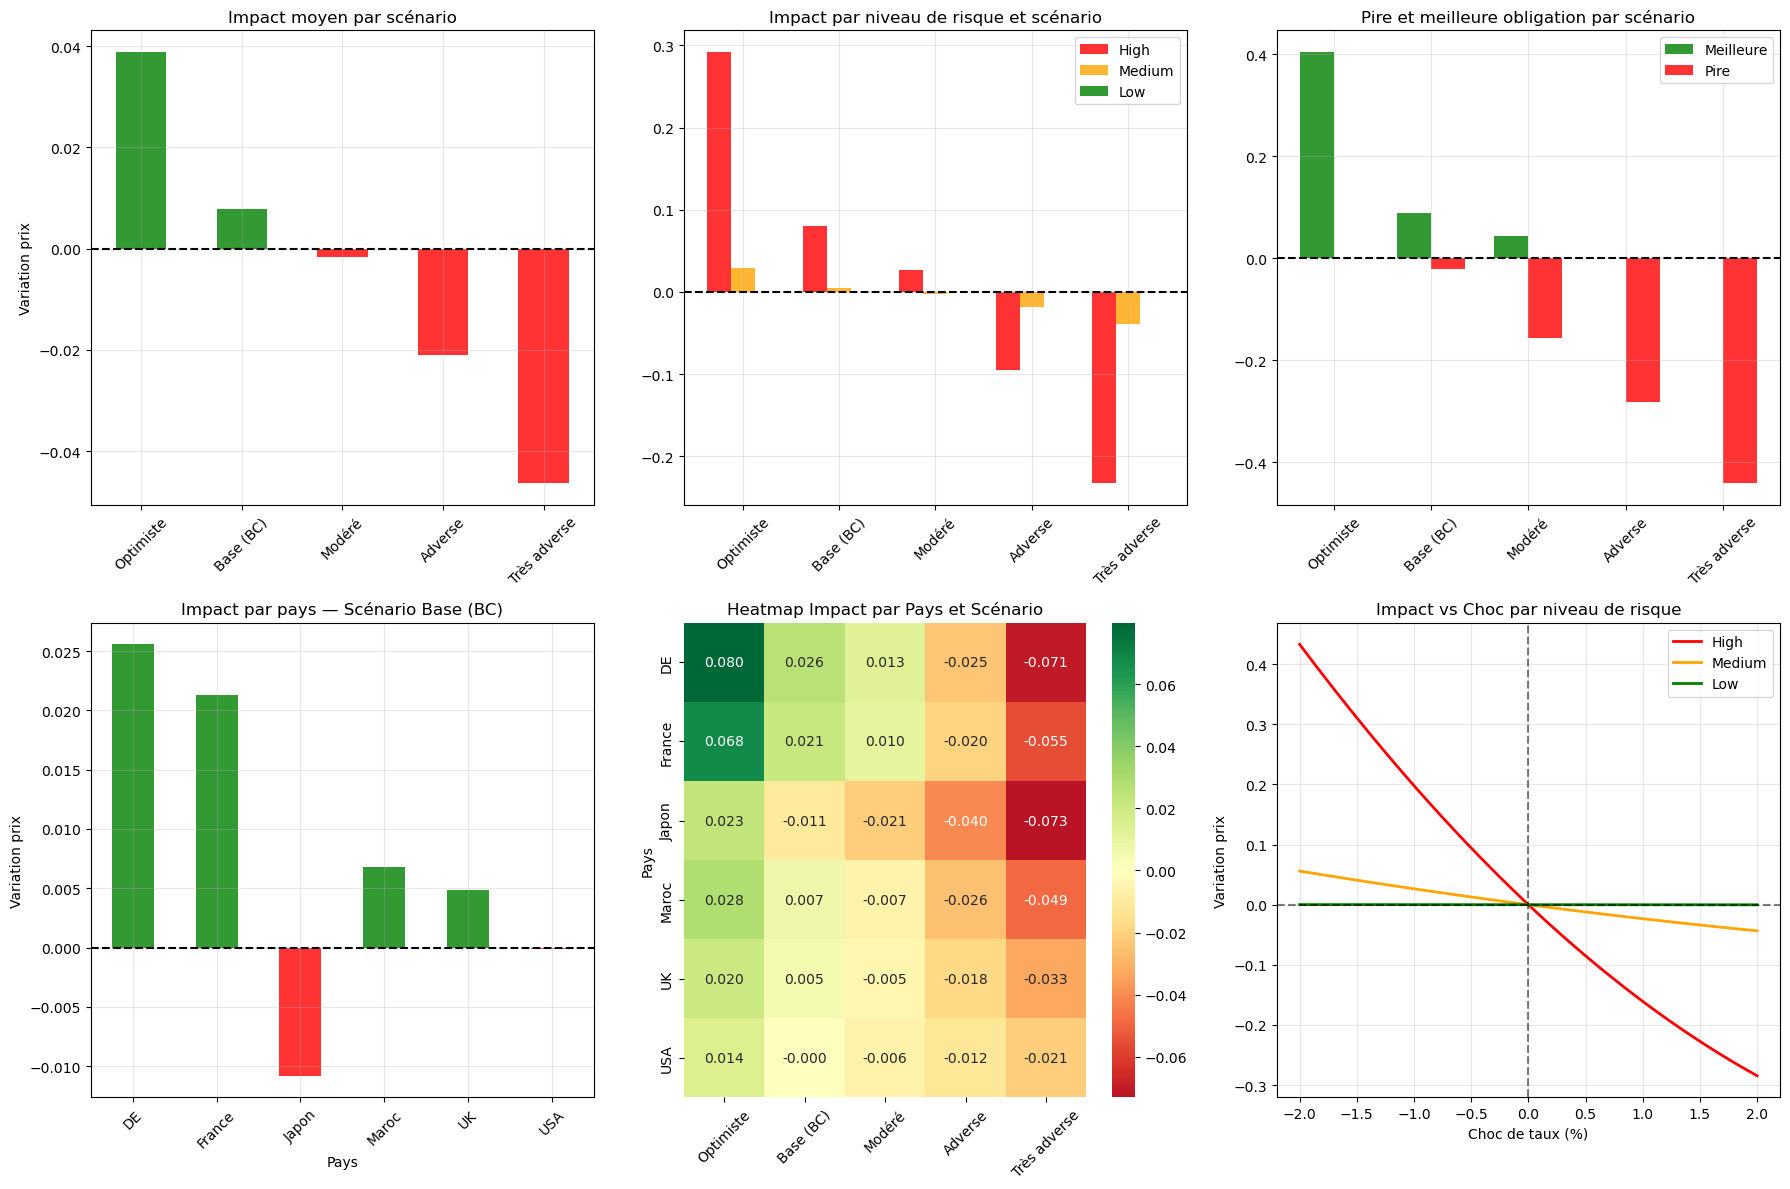

In [59]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

scenarios_names = list(resultats_scenarios.keys())
colors_bar = ['green' if x > 0 else 'red' 
              for x in df_scenarios['impact_moyen']]

# 1. Impact moyen par scénario
df_scenarios['impact_moyen'].plot(
    kind='bar', ax=axes[0,0], color=colors_bar, alpha=0.8)
axes[0,0].axhline(y=0, color='black', linestyle='--')
axes[0,0].set_title('Impact moyen par scénario')
axes[0,0].set_ylabel('Variation prix')
axes[0,0].tick_params(axis='x', rotation=45)
axes[0,0].grid(True, alpha=0.3)

# 2. Impact par cluster et scénario
x = np.arange(len(scenarios_names))
width = 0.25

high_impacts   = [resultats_scenarios[s]['impact_High']   for s in scenarios_names]
medium_impacts = [resultats_scenarios[s]['impact_Medium'] for s in scenarios_names]
low_impacts    = [resultats_scenarios[s]['impact_Low']    for s in scenarios_names]

axes[0,1].bar(x - width, high_impacts,   width, label='High',   color='red',    alpha=0.8)
axes[0,1].bar(x,          medium_impacts, width, label='Medium', color='orange', alpha=0.8)
axes[0,1].bar(x + width,  low_impacts,    width, label='Low',    color='green',  alpha=0.8)
axes[0,1].axhline(y=0, color='black', linestyle='--')
axes[0,1].set_title('Impact par niveau de risque et scénario')
axes[0,1].set_xticks(x)
axes[0,1].set_xticklabels(scenarios_names, rotation=45)
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# 3. Pire et meilleure obligation par scénario
pires     = [resultats_scenarios[s]['pire_oblig']     for s in scenarios_names]
meilleures= [resultats_scenarios[s]['meilleure_oblig'] for s in scenarios_names]

x = np.arange(len(scenarios_names))
width = 0.35
axes[0,2].bar(x - width/2, meilleures, width, label='Meilleure', color='green', alpha=0.8)
axes[0,2].bar(x + width/2, pires,      width, label='Pire',      color='red',   alpha=0.8)
axes[0,2].axhline(y=0, color='black', linestyle='--')
axes[0,2].set_title('Pire et meilleure obligation par scénario')
axes[0,2].set_xticks(x)
axes[0,2].set_xticklabels(scenarios_names, rotation=45)
axes[0,2].legend()
axes[0,2].grid(True, alpha=0.3)

# 4. Impact par pays — scénario Base (BC)
dataset['choc_Base (BC)'] = dataset['Pays'].map(chocs_par_pays)
impact_pays = dataset.groupby('Pays')['variation_prix_future'].mean()
colors_pays = ['green' if x > 0 else 'red' for x in impact_pays]
impact_pays.plot(kind='bar', ax=axes[1,0], color=colors_pays, alpha=0.8)
axes[1,0].axhline(y=0, color='black', linestyle='--')
axes[1,0].set_title('Impact par pays — Scénario Base (BC)')
axes[1,0].set_ylabel('Variation prix')
axes[1,0].tick_params(axis='x', rotation=45)
axes[1,0].grid(True, alpha=0.3)

# 5. Heatmap impact par pays et scénario
heatmap_data = {}
for scenario, chocs in scenarios.items():
    dataset[f'choc_{scenario}'] = dataset['Pays'].map(chocs)
    dataset[f'var_{scenario}'] = (
        -dataset['duration_mod'] * dataset[f'choc_{scenario}']
        + 0.5 * dataset['convexity'] * dataset[f'choc_{scenario}']**2
    )
    heatmap_data[scenario] = dataset.groupby('Pays')[f'var_{scenario}'].mean()

heatmap_df = pd.DataFrame(heatmap_data)
sns.heatmap(heatmap_df, annot=True, fmt='.3f', cmap='RdYlGn',
            center=0, ax=axes[1,1])
axes[1,1].set_title('Heatmap Impact par Pays et Scénario')
axes[1,1].tick_params(axis='x', rotation=45)

# 6. Courbe impact vs choc — par cluster
chocs_range = np.linspace(-0.02, 0.02, 100)
dur_high   = float(dataset[dataset['risk_level_ml']=='High']['duration_mod'].mean())
dur_medium = float(dataset[dataset['risk_level_ml']=='Medium']['duration_mod'].mean())
dur_low    = float(dataset[dataset['risk_level_ml']=='Low']['duration_mod'].mean())
conv_high  = float(dataset[dataset['risk_level_ml']=='High']['convexity'].mean())
conv_medium= float(dataset[dataset['risk_level_ml']=='Medium']['convexity'].mean())
conv_low   = float(dataset[dataset['risk_level_ml']=='Low']['convexity'].mean())

impacts_high   = [-dur_high   * c + 0.5 * conv_high   * c**2 for c in chocs_range]
impacts_medium = [-dur_medium * c + 0.5 * conv_medium * c**2 for c in chocs_range]
impacts_low    = [-dur_low    * c + 0.5 * conv_low    * c**2 for c in chocs_range]

axes[1,2].plot(chocs_range*100, impacts_high,   label='High',   color='red',    linewidth=2)
axes[1,2].plot(chocs_range*100, impacts_medium, label='Medium', color='orange', linewidth=2)
axes[1,2].plot(chocs_range*100, impacts_low,    label='Low',    color='green',  linewidth=2)
axes[1,2].axhline(y=0, color='black', linestyle='--', alpha=0.5)
axes[1,2].axvline(x=0, color='black', linestyle='--', alpha=0.5)
axes[1,2].set_title('Impact vs Choc par niveau de risque')
axes[1,2].set_xlabel('Choc de taux (%)')
axes[1,2].set_ylabel('Variation prix')
axes[1,2].legend()
axes[1,2].grid(True, alpha=0.3)
# Enregistrer Partie 4
plt.savefig('figures/partie4_simulation.png',
            dpi=300, bbox_inches='tight',
            facecolor='white')
plt.tight_layout()
plt.show()

### Partie 5 : Optimisation Portefeuille 

In [60]:
# Filtrer les obligations pour l'optimisation
mask_valid = (
    (dataset['statut'] == 'active') &          # actives uniquement
    (dataset['ytm_calculee'] < 0.20) &         # ytm < 20%
    (dataset['duration_mod'] > 0.1) &          # duration > 0.1 an
    (dataset['prix'] > 10)                      # prix > 10
)

dataset_opt = dataset[mask_valid].copy().reset_index(drop=True)
print(f"Obligations valides pour optimisation : {len(dataset_opt)}")

Obligations valides pour optimisation : 260


In [61]:
# Données de base
mu    = dataset_opt['ytm_calculee'].values      # rendements
dur   = dataset_opt['duration_mod'].values      # durations
conv  = dataset_opt['convexity'].values         # convexités
n     = len(mu)                             # nombre d'obligations
# Taux sans risque par pays
rf_par_pays = {
    'USA'    : float(taux_par_pays['USA'].iloc[-1].iloc[0])    + chocs_par_pays['USA'],
    'DE'     : float(taux_par_pays['DE'].iloc[-1].iloc[0])     + chocs_par_pays['DE'],
    'France' : float(taux_par_pays['France'].iloc[-1].iloc[0]) + chocs_par_pays['France'],
    'UK'     : float(taux_par_pays['UK'].iloc[-1].iloc[0])     + chocs_par_pays['UK'],
    'Japon'  : float(taux_par_pays['Japon'].iloc[-1].iloc[0])  + chocs_par_pays['Japon'],
    'Maroc'  : float(taux_par_pays['Maroc'].iloc[-1].iloc[0])  + chocs_par_pays['Maroc'],
}
# rf global
dataset_opt['rf_pays'] = dataset_opt['Pays'].map(rf_par_pays)
rf = float(dataset_opt['rf_pays'].mean())
print("Taux sans risque par pays :")
for pays, r in rf_par_pays.items():
    print(f"  {pays} : {r*100:.2f}%")
print(f"\nTaux sans risque global : {rf*100:.2f}%")

# Poids actuels équipondérés
w0 = np.ones(n) / n

# Matrice de covariance simplifiée
sigma_i = dur / dur.max()
Sigma = np.outer(sigma_i, sigma_i) * 0.1 + np.diag(sigma_i**2)

# Fonctions utilitaires
def rendement(w):
    return np.dot(w, mu)

def risque(w):
    return np.sqrt(np.dot(w.T, np.dot(Sigma, w)))

def duration_p(w):
    return np.dot(w, dur)

def sharpe(w):
    r = risque(w)
    return (rendement(w) - rf) / r if r > 0 else 0

# Portefeuille actuel
print("\n" + "=" * 40)
print("PORTEFEUILLE ACTUEL (équipondéré)")
print("=" * 40)
print(f"Rendement : {rendement(w0)*100:.2f}%")
print(f"Risque    : {risque(w0)*100:.4f}%")
print(f"Duration  : {duration_p(w0):.2f} ans")
print(f"Sharpe    : {sharpe(w0):.4f}")

Taux sans risque par pays :
  USA : 4.15%
  DE : 2.14%
  France : 2.64%
  UK : 3.39%
  Japon : 1.39%
  Maroc : 4.39%

Taux sans risque global : 2.74%

PORTEFEUILLE ACTUEL (équipondéré)
Rendement : 1.38%
Risque    : 3.3493%
Duration  : 3.50 ans
Sharpe    : -0.4060


In [62]:
# CONTRAINTES ET BORNES COMMUNES
bounds = [(0, 0.05)] * n  # max 5% par obligation

In [63]:
# MÉTHODE 1 — MARKOWITZ (Frontière Efficiente)
print("=" * 50)
print("MÉTHODE 1 — MARKOWITZ")
print("=" * 50)

rendements_cibles = np.linspace(mu.min(), mu.max(), 20)
risques_eff, rendements_eff, weights_eff = [], [], []

for R_cible in rendements_cibles:
    constraints_eff = [
        {'type': 'eq',   'fun': lambda w: np.sum(w) - 1},
        {'type': 'eq',   'fun': lambda w, R=R_cible: rendement(w) - R},
        {'type': 'ineq', 'fun': lambda w: duration_p(w) - 0.5}  # duration >= 0.5
    ]
    result = minimize(risque, w0,
                     method='SLSQP',
                     bounds=bounds,
                     constraints=constraints_eff)
    if result.success:
        risques_eff.append(result.fun)
        rendements_eff.append(R_cible)
        weights_eff.append(result.x)

idx_min = np.argmin(risques_eff)
w_min_var = weights_eff[idx_min]

print(f"Portefeuille variance minimale :")
print(f"  Rendement : {rendements_eff[idx_min]*100:.2f}%")
print(f"  Risque    : {risques_eff[idx_min]*100:.4f}%")
print(f"  Duration  : {duration_p(w_min_var):.2f} ans")
print(f"  Sharpe    : {sharpe(w_min_var):.4f}")

MÉTHODE 1 — MARKOWITZ
Portefeuille variance minimale :
  Rendement : 2.05%
  Risque    : 0.4729%
  Duration  : 0.50 ans
  Sharpe    : -1.4636


In [64]:
# MÉTHODE 2 — MAXIMISATION DU SHARPE RATIO

print("\n" + "=" * 50)
print("MÉTHODE 2 — SHARPE RATIO OPTIMAL")
print("=" * 50)

def neg_sharpe(w):
    return -sharpe(w)

constraints_sharpe = [
    {'type': 'eq',   'fun': lambda w: np.sum(w) - 1},
    {'type': 'ineq', 'fun': lambda w: duration_p(w) - 0.5},  # duration >= 0.5
    {'type': 'ineq', 'fun': lambda w: rendement(w) - rf},    # rendement >= rf
]

result_sharpe = minimize(neg_sharpe, w0,
                         method='SLSQP',
                         bounds=bounds,
                         constraints=constraints_sharpe)

w_sharpe = result_sharpe.x

print(f"Portefeuille Sharpe optimal :")
print(f"  Rendement : {rendement(w_sharpe)*100:.2f}%")
print(f"  Risque    : {risque(w_sharpe)*100:.4f}%")
print(f"  Duration  : {duration_p(w_sharpe):.2f} ans")
print(f"  Sharpe    : {sharpe(w_sharpe):.4f}")

top10 = dataset_opt.copy()
top10['poids'] = w_sharpe
top10 = top10[top10['poids'] > 0.001].nlargest(10, 'poids')
print(f"\nTop 10 obligations sélectionnées :")
print(top10[['isin', 'type_obligation', 'Pays',
             'ytm_calculee', 'duration_mod', 'poids']].to_string())


MÉTHODE 2 — SHARPE RATIO OPTIMAL
Portefeuille Sharpe optimal :
  Rendement : 4.07%
  Risque    : 0.5711%
  Duration  : 0.50 ans
  Sharpe    : 2.3189

Top 10 obligations sélectionnées :
         isin type_obligation Pays  ytm_calculee  duration_mod  poids
68  C6900PAJ8            CORP  USA      0.028074      0.271682   0.05
69  68245XAN9            CORP  USA      0.033155      0.271683   0.05
70  C6900PAK5            CORP  USA      0.030736      0.289326   0.05
71  68245XAP4            CORP  USA      0.028693      0.330569   0.05
72  C6900PAL3            CORP  USA      0.030488      0.330662   0.05
73  C6900PAN9            CORP  USA      0.027136      0.120885   0.05
75  C6900PAP4            CORP  USA      0.028256      0.330547   0.05
76  68252BAA5            CORP  USA      0.073034      0.384697   0.05
77  68288AAA5            CORP  USA      0.055159      1.161639   0.05
79  68247YAA3            CORP  USA      0.050216      0.115684   0.05


In [65]:
# MÉTHODE 3 — MINIMISATION DE LA DURATION

print("\n" + "=" * 50)
print("MÉTHODE 3 — DURATION MINIMALE")
print("=" * 50)

constraints_dur = [
    {'type': 'eq',   'fun': lambda w: np.sum(w) - 1},
    {'type': 'ineq', 'fun': lambda w: rendement(w) - rendement(w0)},  # rendement >= actuel
    {'type': 'ineq', 'fun': lambda w: duration_p(w) - 0.5},           # duration >= 0.5
]

result_dur = minimize(duration_p, w0,
                      method='SLSQP',
                      bounds=bounds,
                      constraints=constraints_dur)

w_dur = result_dur.x

print(f"Portefeuille Duration minimale :")
print(f"  Rendement : {rendement(w_dur)*100:.2f}%")
print(f"  Risque    : {risque(w_dur)*100:.4f}%")
print(f"  Duration  : {duration_p(w_dur):.2f} ans")
print(f"  Sharpe    : {sharpe(w_dur):.4f}")
print(f"  Réduction : {(1 - duration_p(w_dur)/duration_p(w0))*100:.1f}%")

# TABLEAU COMPARATIF

print("\n" + "=" * 60)
print("TABLEAU COMPARATIF")
print("=" * 60)

comparatif = pd.DataFrame({
    'Portefeuille' : ['Actuel', 'Var. Minimale', 'Sharpe Opt.', 'Duration Min.'],
    'Rendement %'  : [rendement(w0)*100, rendements_eff[idx_min]*100,
                      rendement(w_sharpe)*100, rendement(w_dur)*100],
    'Risque %'     : [risque(w0)*100, risques_eff[idx_min]*100,
                      risque(w_sharpe)*100, risque(w_dur)*100],
    'Duration'     : [duration_p(w0), duration_p(w_min_var),
                      duration_p(w_sharpe), duration_p(w_dur)],
    'Sharpe'       : [sharpe(w0), sharpe(w_min_var),
                      sharpe(w_sharpe), sharpe(w_dur)]
})
print(comparatif.to_string(index=False))


MÉTHODE 3 — DURATION MINIMALE
Portefeuille Duration minimale :
  Rendement : 1.87%
  Risque    : 0.4868%
  Duration  : 0.50 ans
  Sharpe    : -1.7855
  Réduction : 85.7%

TABLEAU COMPARATIF
 Portefeuille  Rendement %  Risque %  Duration    Sharpe
       Actuel     1.382225  3.349268  3.502443 -0.405995
Var. Minimale     2.049927  0.472875  0.500000 -1.463565
  Sharpe Opt.     4.066451  0.571141  0.500000  2.318939
Duration Min.     1.872818  0.486805  0.500000 -1.785502


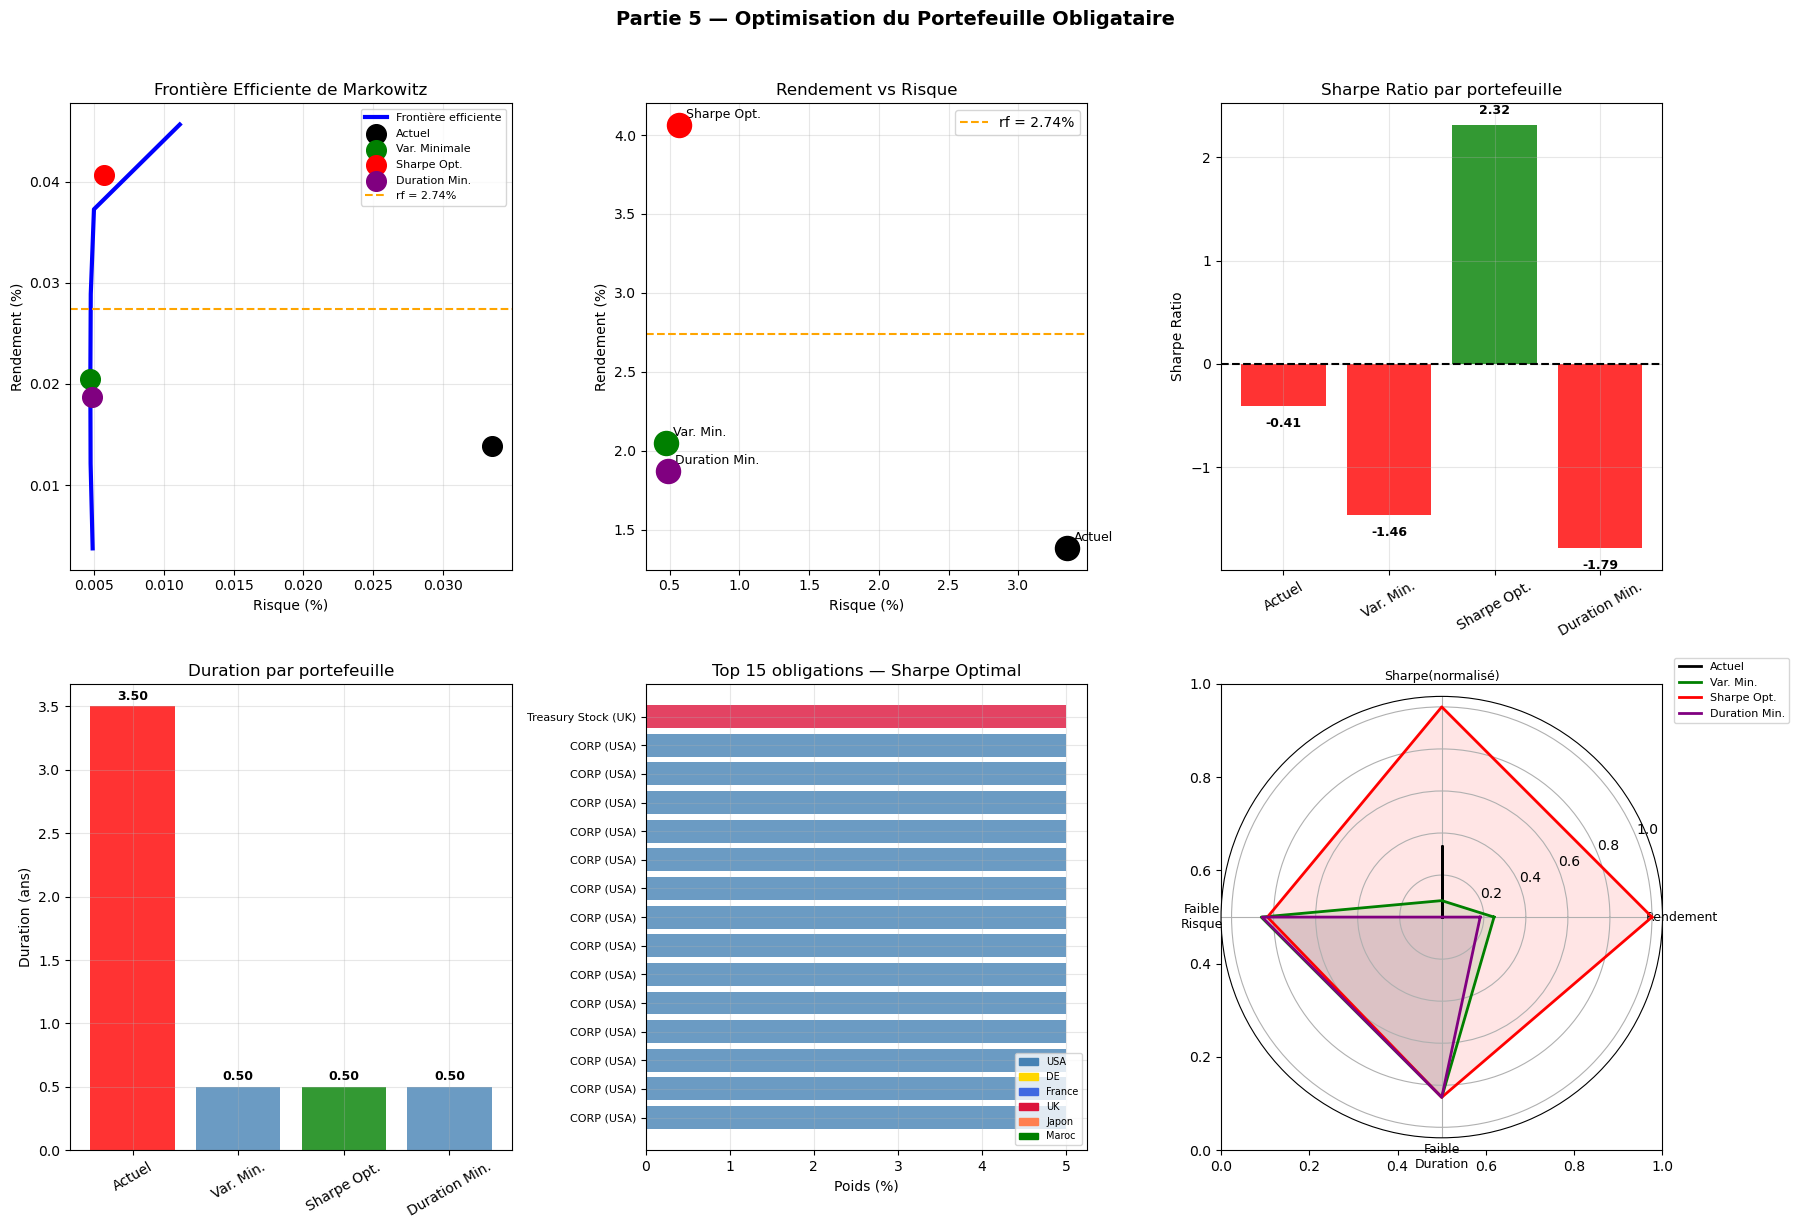

In [66]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# ─── 1. Frontière Efficiente ───────────────────────────────────────────────
axes[0,0].plot(risques_eff, rendements_eff, 'b-', linewidth=3,
               label='Frontière efficiente')
axes[0,0].scatter(risque(w0), rendement(w0),
                  color='black', s=200, zorder=5, label='Actuel')
axes[0,0].scatter(risques_eff[idx_min], rendements_eff[idx_min],
                  color='green', s=200, zorder=5, label='Var. Minimale')
axes[0,0].scatter(risque(w_sharpe), rendement(w_sharpe),
                  color='red', s=200, zorder=5, label='Sharpe Opt.')
axes[0,0].scatter(risque(w_dur), rendement(w_dur),
                  color='purple', s=200, zorder=5, label='Duration Min.')
axes[0,0].axhline(y=rf, color='orange', linestyle='--',
                  linewidth=1.5, label=f'rf = {rf*100:.2f}%')
axes[0,0].set_title('Frontière Efficiente de Markowitz')
axes[0,0].set_xlabel('Risque (%)')
axes[0,0].set_ylabel('Rendement (%)')
axes[0,0].legend(fontsize=8)
axes[0,0].grid(True, alpha=0.3)

# ─── 2. Comparaison Rendement/Risque ───────────────────────────────────────
portefeuilles = ['Actuel', 'Var. Min.', 'Sharpe Opt.', 'Duration Min.']
rendements_comp = [rendement(w0)*100, rendements_eff[idx_min]*100,
                   rendement(w_sharpe)*100, rendement(w_dur)*100]
risques_comp   = [risque(w0)*100, risques_eff[idx_min]*100,
                  risque(w_sharpe)*100, risque(w_dur)*100]
colors_comp    = ['black', 'green', 'red', 'purple']

for i, (p, r, ri, c) in enumerate(zip(portefeuilles, rendements_comp,
                                       risques_comp, colors_comp)):
    axes[0,1].scatter(ri, r, color=c, s=300, zorder=5)
    axes[0,1].annotate(p, (ri, r), textcoords="offset points",
                       xytext=(5, 5), fontsize=9)

axes[0,1].axhline(y=rf*100, color='orange', linestyle='--',
                  linewidth=1.5, label=f'rf = {rf*100:.2f}%')
axes[0,1].set_title('Rendement vs Risque')
axes[0,1].set_xlabel('Risque (%)')
axes[0,1].set_ylabel('Rendement (%)')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

#  3. Comparaison Sharpe 
sharpes = [sharpe(w0), sharpe(w_min_var),
           sharpe(w_sharpe), sharpe(w_dur)]
colors_sharpe = ['red' if s < 0 else 'green' for s in sharpes]

axes[0,2].bar(portefeuilles, sharpes, color=colors_sharpe, alpha=0.8)
axes[0,2].axhline(y=0, color='black', linestyle='--', linewidth=1.5)
axes[0,2].set_title('Sharpe Ratio par portefeuille')
axes[0,2].set_ylabel('Sharpe Ratio')
axes[0,2].tick_params(axis='x', rotation=30)
axes[0,2].grid(True, alpha=0.3)

for i, s in enumerate(sharpes):
    axes[0,2].text(i, s + 0.1 if s >= 0 else s - 0.2,
                   f'{s:.2f}', ha='center', fontsize=9, fontweight='bold')

# 4. Comparaison Duration 
durations = [duration_p(w0), duration_p(w_min_var),
             duration_p(w_sharpe), duration_p(w_dur)]
colors_dur = ['steelblue'] * 4
colors_dur[0] = 'red'     # actuel en rouge
colors_dur[2] = 'green'   # sharpe en vert

axes[1,0].bar(portefeuilles, durations, color=colors_dur, alpha=0.8)
axes[1,0].set_title('Duration par portefeuille')
axes[1,0].set_ylabel('Duration (ans)')
axes[1,0].tick_params(axis='x', rotation=30)
axes[1,0].grid(True, alpha=0.3)

for i, d in enumerate(durations):
    axes[1,0].text(i, d + 0.05, f'{d:.2f}',
                   ha='center', fontsize=9, fontweight='bold')

#  5. Allocation Sharpe Optimal — Top 15 
top15 = dataset_opt.copy()
top15['poids'] = w_sharpe
top15 = top15[top15['poids'] > 0.001].nlargest(15, 'poids')

colors_pays = {
    'USA': 'steelblue', 'DE': 'gold',
    'France': 'royalblue', 'UK': 'crimson',
    'Japon': 'coral', 'Maroc': 'green'
}
bar_colors = [colors_pays.get(p, 'gray') for p in top15['Pays']]

axes[1,1].barh(range(len(top15)), top15['poids']*100,
               color=bar_colors, alpha=0.8)
axes[1,1].set_yticks(range(len(top15)))
axes[1,1].set_yticklabels(
    [f"{row['type_obligation']} ({row['Pays']})"
     for _, row in top15.iterrows()], fontsize=8)
axes[1,1].set_title('Top 15 obligations — Sharpe Optimal')
axes[1,1].set_xlabel('Poids (%)')
axes[1,1].grid(True, alpha=0.3)

# Légende pays
patches = [mpatches.Patch(color=c, label=p)
           for p, c in colors_pays.items()]
axes[1,1].legend(handles=patches, fontsize=7, loc='lower right')

#  6. Radar Chart — Comparaison globale 
categories = ['Rendement', 'Sharpe(normalisé)', 
              'Faible\nRisque', 'Faible\nDuration']
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

ax_radar = fig.add_subplot(2, 3, 6, polar=True)

# Normaliser entre 0 et 1
def normalize(val, min_val, max_val):
    if max_val == min_val:
        return 0
    return (val - min_val) / (max_val - min_val)

rend_vals  = [rendement(w)*100 for w in [w0, w_min_var, w_sharpe, w_dur]]
sharpe_vals= [sharpe(w) for w in [w0, w_min_var, w_sharpe, w_dur]]
risque_vals= [1 - risque(w)*100/max(risque(w0)*100, 0.001)
              for w in [w0, w_min_var, w_sharpe, w_dur]]
dur_vals   = [1 - duration_p(w)/max(duration_p(w0), 0.001)
              for w in [w0, w_min_var, w_sharpe, w_dur]]
portfolios_radar = {
    'Actuel'       : [normalize(rend_vals[0], min(rend_vals), max(rend_vals)),
                      normalize(sharpe_vals[0], min(sharpe_vals), max(sharpe_vals)),
                      risque_vals[0], dur_vals[0]],
    'Var. Min.'    : [normalize(rend_vals[1], min(rend_vals), max(rend_vals)),
                      normalize(sharpe_vals[1], min(sharpe_vals), max(sharpe_vals)),
                      risque_vals[1], dur_vals[1]],
    'Sharpe Opt.'  : [normalize(rend_vals[2], min(rend_vals), max(rend_vals)),
                      normalize(sharpe_vals[2], min(sharpe_vals), max(sharpe_vals)),
                      risque_vals[2], dur_vals[2]],
    'Duration Min.': [normalize(rend_vals[3], min(rend_vals), max(rend_vals)),
                      normalize(sharpe_vals[3], min(sharpe_vals), max(sharpe_vals)),
                      risque_vals[3], dur_vals[3]],
}

colors_radar = ['black', 'green', 'red', 'purple']
for (label, values), color in zip(portfolios_radar.items(), colors_radar):
    values_plot = values + values[:1]
    ax_radar.plot(angles, values_plot, color=color,
                  linewidth=2, label=label)
    ax_radar.fill(angles, values_plot, color=color, alpha=0.1)

ax_radar.set_xticks(angles[:-1])
ax_radar.set_xticklabels(categories, fontsize=9)
ax_radar.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=8)

plt.suptitle('Partie 5 — Optimisation du Portefeuille Obligataire',
             fontsize=14, fontweight='bold', y=1.02)
# Enregistrer Partie 5

plt.savefig('figures/partie5_optimisation.png',
            dpi=300, bbox_inches='tight',
            facecolor='white')
plt.tight_layout()
plt.show()

In [67]:
# ══════════════════════════════════════════════════════════════════════════════
# DÉFINITIONS ET DONNÉES DE BASE
# ══════════════════════════════════════════════════════════════════════════════
mu   = dataset_opt['ytm_calculee'].values      # rendements
dur  = dataset_opt['duration_mod'].values      # durations
conv = dataset_opt['convexity'].values         # convexités
n    = len(mu)                                 # nombre d'obligations

# ── GESTION DYNAMIQUE ET SÉCURISÉE DES TAUX SANS RISQUE PAR PAYS ──────────────
# Vos séries d'origine (taux_par_pays & chocs_par_pays doivent exister en amont)
rf_par_pays_de_base = {
    'USA'    : float(taux_par_pays['USA'].iloc[-1].iloc[0])    + chocs_par_pays['USA'],
    'DE'     : float(taux_par_pays['DE'].iloc[-1].iloc[0])     + chocs_par_pays['DE'],
    'France' : float(taux_par_pays['France'].iloc[-1].iloc[0]) + chocs_par_pays['France'],
    'UK'     : float(taux_par_pays['UK'].iloc[-1].iloc[0])     + chocs_par_pays['UK'],
    'Japon'  : float(taux_par_pays['Japon'].iloc[-1].iloc[0])  + chocs_par_pays['Japon'],
    'Maroc'  : float(taux_par_pays['Maroc'].iloc[-1].iloc[0])  + chocs_par_pays['Maroc'],
}

# Calcul d'un taux de secours global basé sur la moyenne de vos courbes
taux_moyen_secours = np.mean(list(rf_par_pays_de_base.values()))

# Mapping dynamique : s'adapte à TOUS les pays présents dans votre CSV (même les nouveaux)
rf_par_pays = {}
for pays in dataset_opt['Pays'].unique():
    if pays in rf_par_pays_de_base:
        rf_par_pays[pays] = rf_par_pays_de_base[pays]
    else:
        # Secours automatique pour le Canada, la Suisse, l'Australie, etc.
        rf_par_pays[pays] = taux_moyen_secours

# Application du dictionnaire adaptatif sans générer aucun NaN
dataset_opt['rf_pays'] = dataset_opt['Pays'].map(rf_par_pays)
rf = float(dataset_opt['rf_pays'].mean())

# Affichage des taux retenus dans la console
print("Taux sans risque par pays :")
for pays, r in rf_par_pays.items():
    print(f"  {pays} : {r*100:.2f}%")
print(f"\nTaux sans risque global : {rf*100:.2f}%")

# Poids actuels équipondérés
w0 = np.ones(n) / n

# Matrice de covariance simplifiée
sigma_i = dur / dur.max() if dur.max() > 0 else np.ones(n)
Sigma = np.outer(sigma_i, sigma_i) * 0.1 + np.diag(sigma_i**2)

# Fonctions utilitaires d'origine
def rendement(w):
    return np.dot(w, mu)

def risque(w):
    return np.sqrt(np.dot(w.T, np.dot(Sigma, w)))

def duration_p(w):
    return np.dot(w, dur)

def sharpe(w):
    r = risque(w)
    return (rendement(w) - rf) / r if r > 0 else 0

# Portefeuille actuel
print("\n" + "=" * 40)
print("PORTEFEUILLE ACTUEL (équipondéré)")
print("=" * 40)
print(f"Rendement : {rendement(w0)*100:.2f}%")
print(f"Risque    : {risque(w0)*100:.4f}%")
print(f"Duration  : {duration_p(w0):.2f} ans")
print(f"Sharpe    : {sharpe(w0):.4f}")

# ── AJUSTEMENT DYNAMIQUE DES BORNES (Empêche l'impasse mathématique si n < 20) ──
# Si n < 20, forcer un maximum strict de 5% (0.05) bloque l'optimiseur. 
# On ajuste la borne haute à 1/n si nécessaire pour que la somme à 100% soit atteignable.
poids_max_autorise = max(0.05, 1.0 / n)
bounds = [(0, poids_max_autorise)] * n 

# ══════════════════════════════════════════════════════════════════════════════
# MÉTHODE 1 — MARKOWITZ (Frontière Efficiente)
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 50)
print("MÉTHODE 1 — MARKOWITZ")
print("=" * 50)

# Resserrement léger des extrêmes (2% de marge) pour assurer la convergence SLSQP
r_min, r_max = mu.min(), mu.max()
if r_min == r_max:
    rendements_cibles = [r_min]
else:
    marge = (r_max - r_min) * 0.02
    rendements_cibles = np.linspace(r_min + marge, r_max - marge, 20)

risques_eff, rendements_eff, weights_eff = [], [], []

for R_cible in rendements_cibles:
    constraints_eff = [
        {'type': 'eq',   'fun': lambda w: np.sum(w) - 1},
        {'type': 'eq',   'fun': lambda w, R=R_cible: rendement(w) - R},
        {'type': 'ineq', 'fun': lambda w: duration_p(w) - 0.5}  # duration >= 0.5
    ]
    result = minimize(risque, w0, method='SLSQP', bounds=bounds, constraints=constraints_eff)
    if result.success:
        risques_eff.append(result.fun)
        rendements_eff.append(R_cible)
        weights_eff.append(result.x)

# ── SÉCURISATION DU POST-CALCUL MARKOWITZ ─────────────────────────────────────
if len(risques_eff) > 0:
    idx_min = np.argmin(risques_eff)
    w_min_var = weights_eff[idx_min]
    
    print(f"Portefeuille variance minimale :")
    print(f"  Rendement : {rendements_eff[idx_min]*100:.2f}%")
    print(f"  Risque    : {risques_eff[idx_min]*100:.4f}%")
    print(f"  Duration  : {duration_p(w_min_var):.2f} ans")
    print(f"  Sharpe    : {sharpe(w_min_var):.4f}")
else:
    # Sécurité ultime si Markowitz échoue malgré tout (on retient le point initial)
    w_min_var = w0
    risques_eff = [risque(w0)]
    rendements_eff = [rendement(w0)]
    idx_min = 0
    print("⚠️ Frontière efficiente vide. Utilisation du portefeuille par défaut.")

# ══════════════════════════════════════════════════════════════════════════════
# MÉTHODE 2 — MAXIMISATION DU SHARPE RATIO
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 50)
print("MÉTHODE 2 — SHARPE RATIO OPTIMAL")
print("=" * 50)

def neg_sharpe(w):
    return -sharpe(w)

constraints_sharpe = [
    {'type': 'eq',   'fun': lambda w: np.sum(w) - 1},
    {'type': 'ineq', 'fun': lambda w: duration_p(w) - 0.5},  # duration >= 0.5
    {'type': 'ineq', 'fun': lambda w: rendement(w) - rf},    # rendement >= rf
]

result_sharpe = minimize(neg_sharpe, w0, method='SLSQP', bounds=bounds, constraints=constraints_sharpe)

# Fallback si échec de convergence
w_sharpe = result_sharpe.x if result_sharpe.success else w0

print(f"Portefeuille Sharpe optimal :")
print(f"  Rendement : {rendement(w_sharpe)*100:.2f}%")
print(f"  Risque    : {risque(w_sharpe)*100:.4f}%")
print(f"  Duration  : {duration_p(w_sharpe):.2f} ans")
print(f"  Sharpe    : {sharpe(w_sharpe):.4f}")

# Extraction du Top 10 des lignes du portefeuille
top10 = dataset_opt.copy()
top10['poids'] = w_sharpe
top10 = top10[top10['poids'] > 0.001].nlargest(10, 'poids')
print(f"\nTop 10 obligations sélectionnées :")
# Correction du nom de la colonne pour correspondre à votre fichier d'origine : 'type'
colonne_type = 'type' if 'type' in top10.columns else 'type_obligation'
print(top10[['isin', colonne_type, 'Pays', 'ytm_calculee', 'duration_mod', 'poids']].to_string())

# ══════════════════════════════════════════════════════════════════════════════
# MÉTHODE 3 — MINIMISATION DE LA DURATION
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 50)
print("MÉTHODE 3 — DURATION MINIMALE")
print("=" * 50)

constraints_dur = [
    {'type': 'eq',   'fun': lambda w: np.sum(w) - 1},
    {'type': 'ineq', 'fun': lambda w: rendement(w) - rendement(w0)},  # rendement >= actuel
    {'type': 'ineq', 'fun': lambda w: duration_p(w) - 0.5},           # duration >= 0.5
]

result_dur = minimize(duration_p, w0, method='SLSQP', bounds=bounds, constraints=constraints_dur)

# Fallback si échec de convergence
w_dur = result_dur.x if result_dur.success else w0

print(f"Portefeuille Duration minimale :")
print(f"  Rendement : {rendement(w_dur)*100:.2f}%")
print(f"  Risque    : {risque(w_dur)*100:.4f}%")
print(f"  Duration  : {duration_p(w_dur):.2f} ans")
print(f"  Sharpe    : {sharpe(w_dur):.4f}")
print(f"  Réduction : {(1 - duration_p(w_dur)/duration_p(w0))*100:.1f}%")

# ══════════════════════════════════════════════════════════════════════════════
# TABLEAU COMPARATIF FINAL
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("TABLEAU COMPARATIF")
print("=" * 60)

comparatif = pd.DataFrame({
    'Portefeuille' : ['Actuel', 'Var. Minimale', 'Sharpe Opt.', 'Duration Min.'],
    'Rendement %'  : [rendement(w0)*100, rendements_eff[idx_min]*100, rendement(w_sharpe)*100, rendement(w_dur)*100],
    'Risque %'     : [risque(w0)*100, risques_eff[idx_min]*100, risque(w_sharpe)*100, risque(w_dur)*100],
    'Duration'     : [duration_p(w0), duration_p(w_min_var), duration_p(w_sharpe), duration_p(w_dur)],
    'Sharpe'       : [sharpe(w0), sharpe(w_min_var), sharpe(w_sharpe), sharpe(w_dur)]
})
print(comparatif.to_string(index=False))


Taux sans risque par pays :
  USA : 4.15%
  DE : 2.14%
  Maroc : 4.39%
  UK : 3.39%
  Japon : 1.39%

Taux sans risque global : 2.74%

PORTEFEUILLE ACTUEL (équipondéré)
Rendement : 1.38%
Risque    : 3.3493%
Duration  : 3.50 ans
Sharpe    : -0.4060

MÉTHODE 1 — MARKOWITZ
Portefeuille variance minimale :
  Rendement : 2.23%
  Risque    : 0.4730%
  Duration  : 0.50 ans
  Sharpe    : -1.0732

MÉTHODE 2 — SHARPE RATIO OPTIMAL
Portefeuille Sharpe optimal :
  Rendement : 4.07%
  Risque    : 0.5711%
  Duration  : 0.50 ans
  Sharpe    : 2.3189

Top 10 obligations sélectionnées :
         isin type_obligation Pays  ytm_calculee  duration_mod  poids
68  C6900PAJ8            CORP  USA      0.028074      0.271682   0.05
69  68245XAN9            CORP  USA      0.033155      0.271683   0.05
70  C6900PAK5            CORP  USA      0.030736      0.289326   0.05
71  68245XAP4            CORP  USA      0.028693      0.330569   0.05
72  C6900PAL3            CORP  USA      0.030488      0.330662   0.05
73  

2026-05-25 20:59:55.242 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-25 20:59:58.085 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-25 21:00:03.632 
  command:

    streamlit run D:\ANACONDA JUPYTER\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-05-25 21:00:03.633 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-25 21:00:03.636 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

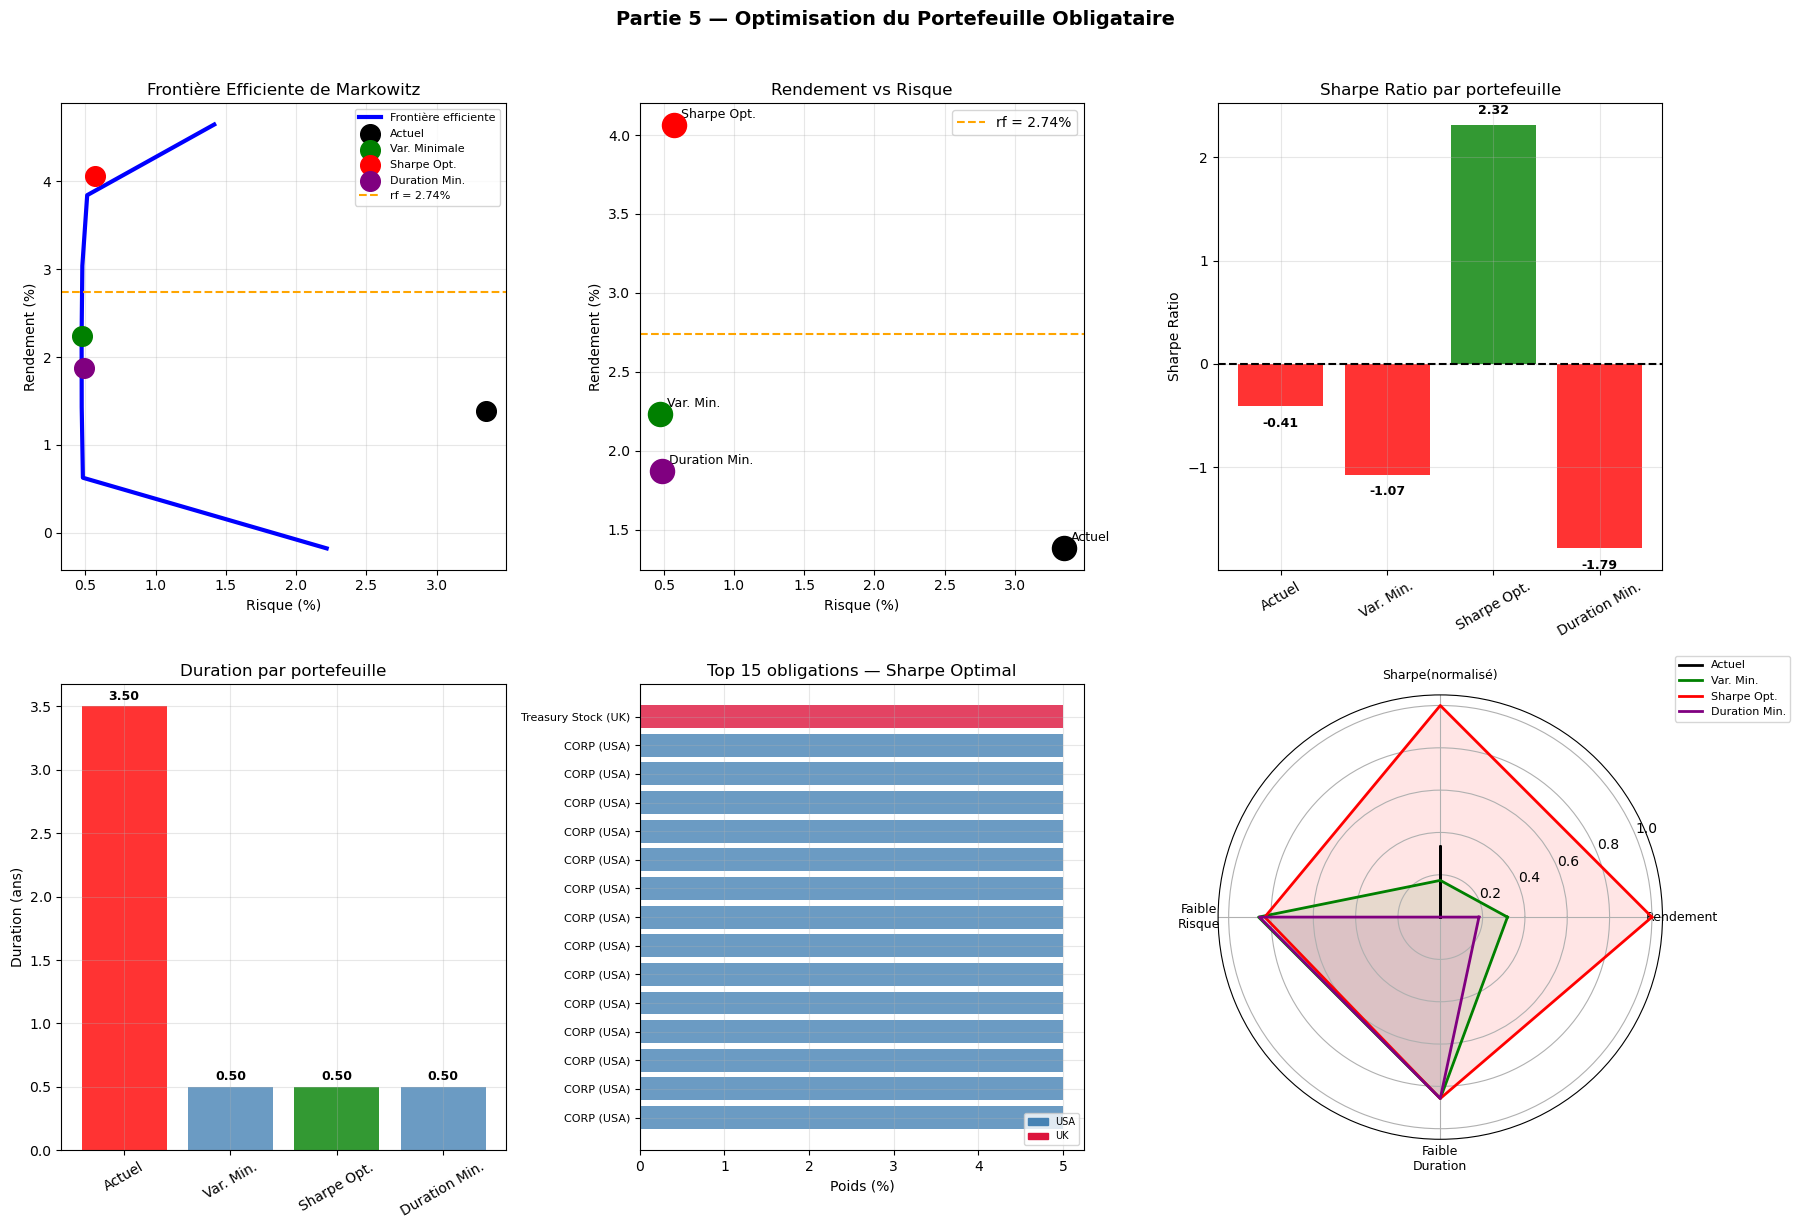

In [68]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches  # ← Requis pour les légendes personnalisées (Patch)
import streamlit as st

# Initialisation de la grille Matplotlib (2 lignes, 3 colonnes)
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# ─── 1. Frontière Efficiente ───────────────────────────────────────────────
if len(risques_eff) > 1:
    # On trace la ligne uniquement si on dispose de plusieurs points distincts
    axes[0,0].plot([r * 100 for r in risques_eff], [m * 100 for m in rendements_eff], 
                   'b-', linewidth=3, label='Frontière efficiente')
elif len(risques_eff) == 1:
    axes[0,0].scatter([risques_eff[0] * 100], [rendements_eff[0] * 100], 
                      color='blue', s=100, label='Point frontière')

axes[0,0].scatter(risque(w0)*100, rendement(w0)*100,
                  color='black', s=200, zorder=5, label='Actuel')

# Sécurité pour l'extraction de l'index de variance minimale
val_risk_min = risques_eff[idx_min]*100 if len(risques_eff) > 0 else risque(w0)*100
val_rend_min = rendements_eff[idx_min]*100 if len(risques_eff) > 0 else rendement(w0)*100
axes[0,0].scatter(val_risk_min, val_rend_min,
                  color='green', s=200, zorder=5, label='Var. Minimale')

axes[0,0].scatter(risque(w_sharpe)*100, rendement(w_sharpe)*100,
                  color='red', s=200, zorder=5, label='Sharpe Opt.')
axes[0,0].scatter(risque(w_dur)*100, rendement(w_dur)*100,
                  color='purple', s=200, zorder=5, label='Duration Min.')

axes[0,0].axhline(y=rf*100, color='orange', linestyle='--',
                  linewidth=1.5, label=f'rf = {rf*100:.2f}%')
axes[0,0].set_title('Frontière Efficiente de Markowitz')
axes[0,0].set_xlabel('Risque (%)')
axes[0,0].set_ylabel('Rendement (%)')
axes[0,0].legend(fontsize=8)
axes[0,0].grid(True, alpha=0.3)

# ─── 2. Comparaison Rendement/Risque ───────────────────────────────────────
portefeuilles = ['Actuel', 'Var. Min.', 'Sharpe Opt.', 'Duration Min.']
rendements_comp = [rendement(w0)*100, val_rend_min, rendement(w_sharpe)*100, rendement(w_dur)*100]
risques_comp    = [risque(w0)*100, val_risk_min, risque(w_sharpe)*100, risque(w_dur)*100]
colors_comp     = ['black', 'green', 'red', 'purple']

for i, (p, r, ri, c) in enumerate(zip(portefeuilles, rendements_comp, risques_comp, colors_comp)):
    axes[0,1].scatter(ri, r, color=c, s=300, zorder=5)
    axes[0,1].annotate(p, (ri, r), textcoords="offset points", xytext=(5, 5), fontsize=9)

axes[0,1].axhline(y=rf*100, color='orange', linestyle='--', linewidth=1.5, label=f'rf = {rf*100:.2f}%')
axes[0,1].set_title('Rendement vs Risque')
axes[0,1].set_xlabel('Risque (%)')
axes[0,1].set_ylabel('Rendement (%)')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# ─── 3. Comparaison Sharpe ──────────────────────────────────────────────────
sharpes = [sharpe(w0), sharpe(w_min_var), sharpe(w_sharpe), sharpe(w_dur)]
colors_sharpe = ['red' if s < 0 else 'green' for s in sharpes]

axes[0,2].bar(portefeuilles, sharpes, color=colors_sharpe, alpha=0.8)
axes[0,2].axhline(y=0, color='black', linestyle='--', linewidth=1.5)
axes[0,2].set_title('Sharpe Ratio par portefeuille')
axes[0,2].set_ylabel('Sharpe Ratio')
axes[0,2].tick_params(axis='x', rotation=30)
axes[0,2].grid(True, alpha=0.3)

for i, s in enumerate(sharpes):
    axes[0,2].text(i, s + 0.1 if s >= 0 else s - 0.2, f'{s:.2f}', ha='center', fontsize=9, fontweight='bold')

# ─── 4. Comparaison Duration ────────────────────────────────────────────────
durations = [duration_p(w0), duration_p(w_min_var), duration_p(w_sharpe), duration_p(w_dur)]
colors_dur = ['steelblue'] * 4
colors_dur[0] = 'red'     # actuel en rouge
colors_dur[2] = 'green'   # sharpe en vert

axes[1,0].bar(portefeuilles, durations, color=colors_dur, alpha=0.8)
axes[1,0].set_title('Duration par portefeuille')
axes[1,0].set_ylabel('Duration (ans)')
axes[1,0].tick_params(axis='x', rotation=30)
axes[1,0].grid(True, alpha=0.3)

for i, d in enumerate(durations):
    axes[1,0].text(i, d + 0.05, f'{d:.2f}', ha='center', fontsize=9, fontweight='bold')

# ─── 5. Allocation Sharpe Optimal — Top 15 ──────────────────────────────────
top15 = dataset_opt.copy()
top15['poids'] = w_sharpe
top15 = top15[top15['poids'] > 0.001].nlargest(15, 'poids')

colors_pays = {
    'USA': 'steelblue', 'DE': 'gold', 'Germany': 'gold',
    'France': 'royalblue', 'UK': 'crimson',
    'Japon': 'coral', 'Japan': 'coral', 'Maroc': 'green'
}
bar_colors = [colors_pays.get(p, 'gray') for p in top15['Pays']]

# Détection de la colonne descriptive de l'obligation
nom_col_type = 'type' if 'type' in top15.columns else 'type_obligation'

axes[1,1].barh(range(len(top15)), top15['poids']*100, color=bar_colors, alpha=0.8)
axes[1,1].set_yticks(range(len(top15)))
axes[1,1].set_yticklabels([f"{row[nom_col_type]} ({row['Pays']})" for _, row in top15.iterrows()], fontsize=8)
axes[1,1].set_title('Top 15 obligations — Sharpe Optimal')
axes[1,1].set_xlabel('Poids (%)')
axes[1,1].grid(True, alpha=0.3)

# Légende pays adaptative
patches = [mpatches.Patch(color=c, label=p) for p, c in colors_pays.items() if p in top15['Pays'].unique()]
if patches:
    axes[1,1].legend(handles=patches, fontsize=7, loc='lower right')

# ─── 6. Radar Chart — Comparaison globale (Axe Dédié) ───────────────────────
categories = ['Rendement', 'Sharpe(normalisé)', 'Faible\nRisque', 'Faible\nDuration']
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

# CORRECTION CRUCIALE : Supprimer l'axe standard 2D initialisé à la case [1,2] 
# pour le remplacer par une projection polaire propre sans superposition de grilles.
fig.delaxes(axes[1,2])
ax_radar = fig.add_subplot(2, 3, 6, polar=True)

# Fonction de normalisation locale sécurisée
def normalize(val, min_val, max_val):
    if max_val == min_val:
        return 1.0
    return (val - min_val) / (max_val - min_val)

rend_vals   = [rendement(w)*100 for w in [w0, w_min_var, w_sharpe, w_dur]]
sharpe_vals = [sharpe(w) for w in [w0, w_min_var, w_sharpe, w_dur]]
risque_vals = [1 - risque(w)*100/max(risque(w0)*100, 0.001) for w in [w0, w_min_var, w_sharpe, w_dur]]
dur_vals    = [1 - duration_p(w)/max(duration_p(w0), 0.001) for w in [w0, w_min_var, w_sharpe, w_dur]]

portfolios_radar = {
    'Actuel'       : [normalize(rend_vals[0], min(rend_vals), max(rend_vals)),
                      normalize(sharpe_vals[0], min(sharpe_vals), max(sharpe_vals)),
                      risque_vals[0], dur_vals[0]],
    'Var. Min.'    : [normalize(rend_vals[1], min(rend_vals), max(rend_vals)),
                      normalize(sharpe_vals[1], min(sharpe_vals), max(sharpe_vals)),
                      risque_vals[1], dur_vals[1]],
    'Sharpe Opt.'  : [normalize(rend_vals[2], min(rend_vals), max(rend_vals)),
                      normalize(sharpe_vals[2], min(sharpe_vals), max(sharpe_vals)),
                      risque_vals[2], dur_vals[2]],
    'Duration Min.': [normalize(rend_vals[3], min(rend_vals), max(rend_vals)),
                      normalize(sharpe_vals[3], min(sharpe_vals), max(sharpe_vals)),
                      risque_vals[3], dur_vals[3]],
}

colors_radar = ['black', 'green', 'red', 'purple']
for (label, values), color in zip(portfolios_radar.items(), colors_radar):
    values_plot = values + values[:1]
    ax_radar.plot(angles, values_plot, color=color, linewidth=2, label=label)
    ax_radar.fill(angles, values_plot, color=color, alpha=0.1)

ax_radar.set_xticks(angles[:-1])
ax_radar.set_xticklabels(categories, fontsize=9)
ax_radar.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=8)

# ─── FINALISATION ET RENDU ──────────────────────────────────────────────────
plt.suptitle('Partie 5 — Optimisation du Portefeuille Obligataire', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()

# Sauvegarde locale de l'image
plt.savefig('figures/partie5_optimisation.png', dpi=300, bbox_inches='tight', facecolor='white')

# Affichage direct sur l'interface Streamlit
st.pyplot(fig)